/var/folders/5g/7cwc8n193kz9d4h5lc3ky_0c0000gn/T/ipykernel_21608/3482254885.py:28: RuntimeWarning: invalid value encountered in log
  samples_y = np.log(samples_x[(samples_x > 0)&(np.log(samples_x) >= -1) & (np.log(samples_x) <= 1)])
/var/folders/5g/7cwc8n193kz9d4h5lc3ky_0c0000gn/T/ipykernel_21608/3482254885.py:41: RuntimeWarning: invalid value encountered in log
  samples_y2 = np.log(samples_x[(samples_x > 0)&(np.log(samples_x) >= -1) ])


MLE_log 结果: μ = 0.0198, σ = 0.4360
MLE 结果: μ = 1.0994, σ = 0.4194
OLS 结果: μ = 0.0715, σ = 0.4491


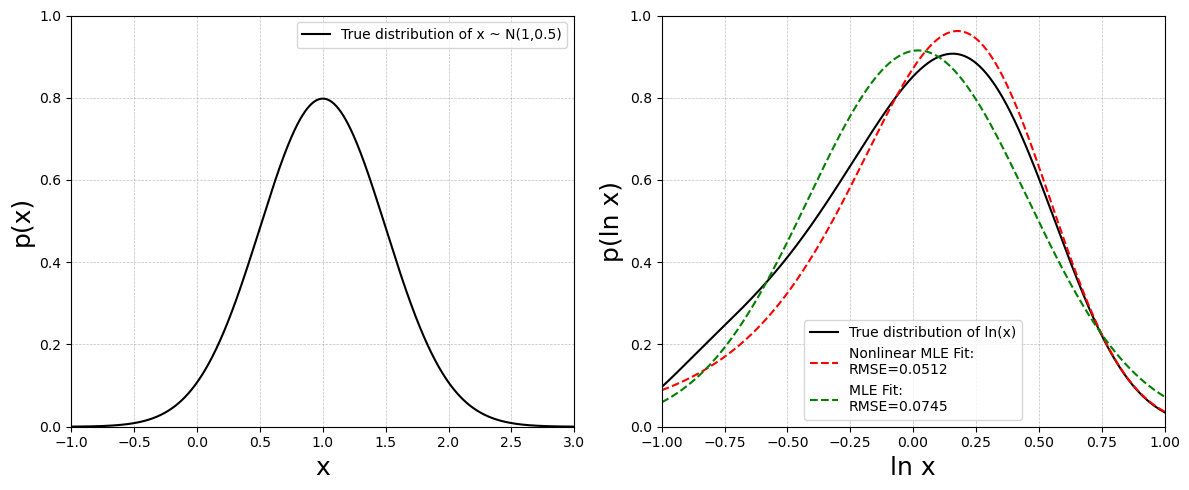

0.05120578333256169
RMSE (MLE via ln(x)): 0.07450


In [344]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.stats import gaussian_kde
def neg_log_likelihood(params, y_data):
    mu, sigma = params
    n = len(y_data)
    x_data = np.exp(y_data)  # y = ln(x) ⇒ x = e^y
    term1 = n/2 * np.log(2 * np.pi)
    term2 = n * np.log(sigma)
    term3 = np.sum((x_data - mu)**2) / (2 * sigma**2)
    term4 = -np.sum(y_data)  # 因为 f_Y(y) 包含 e^y 项
    return term1 + term2 + term3 + term4
def compute_rmse(est, true):
    return np.sqrt(np.mean((est - true)**2))
# 参数
x0 = 1.0        # 均值
sigma_x = 0.5   # 标准差

# 构造 x 和 ln(x)
x = np.linspace(-1, 3, 10000)
x_pdf = norm.pdf(x, loc=x0, scale=sigma_x)

mu, sigma = 1, 0.5
samples_x = np.random.normal(mu, sigma, 1000000)

# 计算 y = ln(x)，并过滤掉 x <= 0 和 y 超出 [-1, 1] 的情况
samples_y = np.log(samples_x[(samples_x > 0)&(np.log(samples_x) >= -1) & (np.log(samples_x) <= 1)])
####

def neg_log_likelihood2(params, data, lower=-1, upper=1):
    mu, sigma = params
    sigma = max(sigma, 1e-6)
    n = len(data)
    # 截断修正项：对数归一化因子
    Z = norm.cdf(upper, loc=mu, scale=sigma) - norm.cdf(lower, loc=mu, scale=sigma)
    log_likelihood = -np.sum(norm.logpdf(data, loc=mu, scale=sigma)) + n * np.log(Z)
    return log_likelihood

# 初始猜测（例如样本均值和标准差）
samples_y2 = np.log(samples_x[(samples_x > 0)&(np.log(samples_x) >= -1) ])
initial_guess2 = [np.mean(samples_y), np.std(samples_y)]
result2 = minimize(
    fun=neg_log_likelihood2,
    x0=initial_guess2,
    args=(samples_y,),
    bounds=[(-1, 1), (1e-6, None)]  # sigma > 0
)

mu_mle2, sigma_mle2 = result2.x



y_grid = np.linspace(-1, 1, 10000)


# 绘制 MLE 拟合的正态分布
pdf_mle = norm.pdf(y_grid, loc=mu_mle2, scale=sigma_mle2)

rmse_mle_norm1 = compute_rmse(pdf_mle, pdf)
print(f"MLE_log 结果: μ = {mu_mle2:.4f}, σ = {sigma_mle2:.4f}")
#####
# 使用 scipy.stats.gaussian_kde 计算 KDE
kde = gaussian_kde(samples_y, bw_method=0.4)  # bw_method 控制平滑程度
y_grid = np.linspace(-1, 1, 10000)  # 在 [-1, 1] 上均匀采样
pdf = kde(y_grid)  # 计算概率密度

initial_guess = [1.0, 0.5]  # 初始猜测 (μ, σ)
result = minimize(
    fun=neg_log_likelihood,
    x0=initial_guess,
    args=(samples_y,),
    bounds=[(None, None), (1e-6, None)]  # σ > 0
)

mu_mle, sigma_mle = result.x
print(f"MLE 结果: μ = {mu_mle:.4f}, σ = {sigma_mle:.4f}")
# 用 MLE 估计的参数生成新的 x 和 y
samples_x_mle = np.random.normal(mu_mle, sigma_mle, 100000)
samples_x_mle = samples_x_mle[samples_x_mle > 0]
samples_y_mle = np.log(samples_x_mle)
#samples_y_mle = samples_y_mle[(samples_y_mle >= -1) & (samples_y_mle <= 1)]

# 计算 KDE
kde_original = gaussian_kde(samples_y, bw_method=0.4)
kde_mle = gaussian_kde(samples_y_mle, bw_method=0.4)
y_grid = np.linspace(-1, 1, 10000)
MLE_exp_ols = compute_rmse(kde_mle(y_grid), pdf)

# 绘图
#plt.plot(y_grid, kde_mle(y_grid), 'r--', label=f'MLE Fit: μ={mu_mle:.3f}, σ={sigma_mle:.3f}')

# 近似分布 1：OLS 假设的近似 N(ln(x0), σx/x0)
def ols_rmse_loss(params):
    mu, sigma = params
    pdf_ols = norm.pdf(y_grid, loc=mu, scale=np.abs(sigma))
    return compute_rmse(pdf_ols, pdf)

result_ols = minimize(ols_rmse_loss, [0.0, 0.5], bounds=[(-1, 1), (1e-6, 2)])
mu_ols, sigma_ols = result_ols.x
pdf_ols = norm.pdf(y_grid, loc=mu_ols, scale=sigma_ols)
rmse_ols = compute_rmse(pdf_ols, pdf)

lnx_ols_mu = np.log(x0)
lnx_ols_sigma = sigma_x / x0
lnx_ols_pdf = norm.pdf(lnx, loc=lnx_ols_mu, scale=lnx_ols_sigma)

print(f"OLS 结果: μ = {mu_ols:.4f}, σ = {sigma_ols:.4f}")

# 作图
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# 图 (a)
axs[0].plot(x, x_pdf, 'k-', label='True distribution of x ~ N(1,0.5)')
axs[0].set_xlabel('x', fontsize=18)
axs[0].set_ylabel('p(x)', fontsize=18)
axs[0].set_xlim([-1, 3])
axs[0].set_ylim([0, 1])
axs[0].grid(True, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
axs[0].legend()
# 图 (b)
'''axs[1].plot(y_grid, pdf, 'k-', label='True distribution of ln(x)')
axs[1].plot(lnx, lnx_ols_pdf, 'r--', label='N(ln x0, σ/x0)')
axs[1].plot(y_grid, pdf_ols, 'r--', label=f'OLS Fit\nμ={mu_ols:.3f}, σ={sigma_ols:.3f}\nRMSE={rmse_ols:.4f}')

axs[1].set_xlabel('ln x')
axs[1].set_ylabel('p(ln x)')
axs[1].set_xlim([-1, 1])
axs[1].set_ylim([0, 1])
axs[1].legend()
'''
# 图 (c)
axs[1].plot(y_grid, pdf, 'k-', label='True distribution of ln(x)')
axs[1].plot(y_grid, kde_mle(y_grid), 'r--', label=f'Nonlinear MLE Fit: \nRMSE={MLE_exp_ols:.4f}')
axs[1].plot(y_grid, pdf_mle, 'g--', label=f'MLE Fit: \nRMSE={rmse_mle_norm1:.4f}')

axs[1].set_xlabel('ln x', fontsize=18)
axs[1].set_ylabel('p(ln x)', fontsize=18)
axs[1].set_xlim([-1, 1])
axs[1].set_ylim([0, 1])
axs[1].legend()
axs[1].grid(True, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
plt.tight_layout()
plt.savefig('distribution_comparison.png', dpi=300, bbox_inches='tight')  # 高分辨率PNG
plt.show()
print(MLE_exp_ols)
print(f"RMSE (MLE via ln(x)): {rmse_mle_norm1:.5f}")


/var/folders/5g/7cwc8n193kz9d4h5lc3ky_0c0000gn/T/ipykernel_21608/1184283936.py:14: RuntimeWarning: invalid value encountered in log
  samples_y = np.log(samples_x[(samples_x > 0) & (np.log(samples_x) >= -1) & (np.log(samples_x) <= 1)])


RMSE between true distribution and OLS approximation: 0.115315
RMSE between true distribution and adjusted approximation: 0.183171


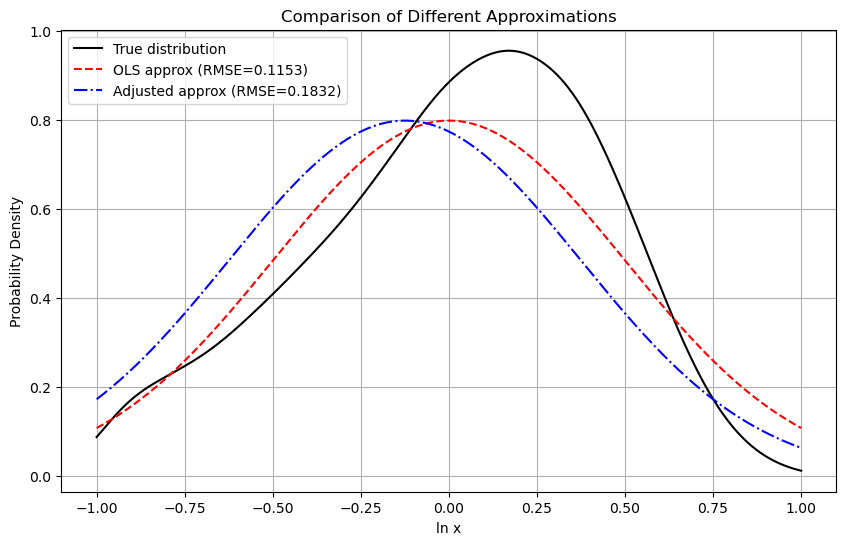

In [226]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, gaussian_kde

# 参数
x0 = 1.0        # 均值
sigma_x = 0.5   # 标准差

# 生成数据
mu, sigma = 1, 0.5
samples_x = np.random.normal(mu, sigma, 100000)

# 计算 y = ln(x)，并过滤
samples_y = np.log(samples_x[(samples_x > 0) & (np.log(samples_x) >= -1) & (np.log(samples_x) <= 1)])

# 计算真实分布的KDE
kde = gaussian_kde(samples_y, bw_method=0.2)
y_grid = np.linspace(-1, 1, 10000)
pdf_true = kde(y_grid)

# 近似分布1：OLS近似 N(ln(x0), σx/x0)
lnx_ols_mu = np.log(x0)
lnx_ols_sigma = sigma_x / x0
pdf_ols = norm.pdf(y_grid, loc=lnx_ols_mu, scale=lnx_ols_sigma)

# 近似分布2：调整后的近似
lnx_mean_true = np.log(x0) - sigma_x**2 / (2 * x0**2)
lnx_std_true = np.sqrt((sigma_x / x0)**2)
pdf_adjusted = norm.pdf(y_grid, loc=lnx_mean_true, scale=lnx_std_true)

# 计算RMSE
rmse_ols = np.sqrt(np.mean((pdf_true - pdf_ols)**2))
rmse_adjusted = np.sqrt(np.mean((pdf_true - pdf_adjusted)**2))

print(f"RMSE between true distribution and OLS approximation: {rmse_ols:.6f}")
print(f"RMSE between true distribution and adjusted approximation: {rmse_adjusted:.6f}")

# 作图比较
plt.figure(figsize=(10, 6))
plt.plot(y_grid, pdf_true, 'k-', label='True distribution')
plt.plot(y_grid, pdf_ols, 'r--', label=f'OLS approx (RMSE={rmse_ols:.4f})')
plt.plot(y_grid, pdf_adjusted, 'b-.', label=f'Adjusted approx (RMSE={rmse_adjusted:.4f})')
plt.xlabel('ln x')
plt.ylabel('Probability Density')
plt.title('Comparison of Different Approximations')
plt.legend()
plt.grid(True)
plt.show()

/var/folders/5g/7cwc8n193kz9d4h5lc3ky_0c0000gn/T/ipykernel_21608/331999508.py:32: RuntimeWarning: invalid value encountered in log
  samples_y = np.log(samples_x[(samples_x > 0)&(np.log(samples_x) >= -1) & (np.log(samples_x) <= 1)])
/var/folders/5g/7cwc8n193kz9d4h5lc3ky_0c0000gn/T/ipykernel_21608/331999508.py:44: RuntimeWarning: invalid value encountered in log
  samples_y2 = np.log(samples_x[(samples_x > 0)&(np.log(samples_x) >= -1) ])


MLE_log 结果: μ = 0.0198, σ = 0.4358
MLE 结果: μ = 1.0994, σ = 0.4194
OLS 结果: μ = 0.0716, σ = 0.4484


/var/folders/5g/7cwc8n193kz9d4h5lc3ky_0c0000gn/T/ipykernel_21608/331999508.py:139: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


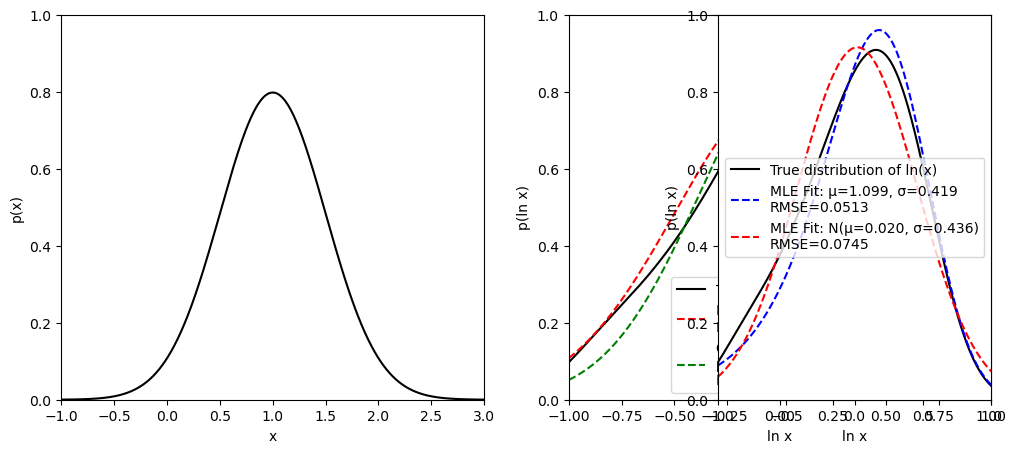

RMSE (MLE via exp): 0.05126
RMSE (MLE via ln(x)): 0.07447


In [320]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.stats import gaussian_kde
from scipy.optimize import minimize

def neg_log_likelihood(params, y_data):
    mu, sigma = params
    n = len(y_data)
    x_data = np.exp(y_data)  # y = ln(x) ⇒ x = e^y
    term1 = n/2 * np.log(2 * np.pi)
    term2 = n * np.log(sigma)
    term3 = np.sum((x_data - mu)**2) / (2 * sigma**2)
    term4 = -np.sum(y_data)  # 因为 f_Y(y) 包含 e^y 项
    return term1 + term2 + term3 + term4

def compute_rmse(est, true):
    return np.sqrt(np.mean((est - true)**2))

# 参数
x0 = 1.0        # 均值
sigma_x = 0.5   # 标准差

# 构造 x 和 ln(x)
x = np.linspace(-1, 3, 10000)
x_pdf = norm.pdf(x, loc=x0, scale=sigma_x)

mu, sigma = 1, 0.5
samples_x = np.random.normal(mu, sigma, 1000000)

# 计算 y = ln(x)，并过滤掉 x <= 0 和 y 超出 [-1, 1] 的情况
samples_y = np.log(samples_x[(samples_x > 0)&(np.log(samples_x) >= -1) & (np.log(samples_x) <= 1)])

def neg_log_likelihood2(params, data, lower=-1, upper=1):
    mu, sigma = params
    sigma = max(sigma, 1e-6)
    n = len(data)
    # 截断修正项：对数归一化因子
    Z = norm.cdf(upper, loc=mu, scale=sigma) - norm.cdf(lower, loc=mu, scale=sigma)
    log_likelihood = -np.sum(norm.logpdf(data, loc=mu, scale=sigma)) + n * np.log(Z)
    return log_likelihood

# 初始猜测（例如样本均值和标准差）
samples_y2 = np.log(samples_x[(samples_x > 0)&(np.log(samples_x) >= -1) ])
initial_guess2 = [np.mean(samples_y), np.std(samples_y)]
result2 = minimize(
    fun=neg_log_likelihood2,
    x0=initial_guess2,
    args=(samples_y,),
    bounds=[(-1, 1), (1e-6, None)]  # sigma > 0
)

mu_mle2, sigma_mle2 = result2.x

y_grid = np.linspace(-1, 1, 10000)

# 绘制 MLE 拟合的正态分布
pdf_mle = norm.pdf(y_grid, loc=mu_mle2, scale=sigma_mle2)

rmse_mle_norm1 = compute_rmse(pdf_mle, kde(y_grid))
print(f"MLE_log 结果: μ = {mu_mle2:.4f}, σ = {sigma_mle2:.4f}")

# 使用 scipy.stats.gaussian_kde 计算 KDE
kde = gaussian_kde(samples_y, bw_method=0.4)  # bw_method 控制平滑程度
pdf = kde(y_grid)  # 计算概率密度

initial_guess = [1.0, 0.5]  # 初始猜测 (μ, σ)
result = minimize(
    fun=neg_log_likelihood,
    x0=initial_guess,
    args=(samples_y,),
    bounds=[(None, None), (1e-6, None)]  # σ > 0
)

mu_mle, sigma_mle = result.x
print(f"MLE 结果: μ = {mu_mle:.4f}, σ = {sigma_mle:.4f}")

# 用 MLE 估计的参数生成新的 x 和 y
samples_x_mle = np.random.normal(mu_mle, sigma_mle, 100000)
samples_x_mle = samples_x_mle[samples_x_mle > 0]
samples_y_mle = np.log(samples_x_mle)

# 计算 KDE
kde_original = gaussian_kde(samples_y, bw_method=0.4)
kde_mle = gaussian_kde(samples_y_mle, bw_method=0.4)
MLE_exp_ols = compute_rmse(kde_mle(y_grid), pdf)

# 近似分布 1：OLS 假设的近似 N(ln(x0), σx/x0)
def ols_rmse_loss(params):
    mu, sigma = params
    pdf_ols = norm.pdf(y_grid, loc=mu, scale=np.abs(sigma))
    return compute_rmse(pdf_ols, pdf)

result_ols = minimize(ols_rmse_loss, [0.0, 0.5], bounds=[(-1, 1), (1e-6, 2)])
mu_ols, sigma_ols = result_ols.x
pdf_ols = norm.pdf(y_grid, loc=mu_ols, scale=sigma_ols)
rmse_ols = compute_rmse(pdf_ols, pdf)

lnx_ols_mu = np.log(x0)
lnx_ols_sigma = sigma_x / x0
lnx = np.linspace(-1, 1, 10000)
lnx_ols_pdf = norm.pdf(lnx, loc=lnx_ols_mu, scale=lnx_ols_sigma)

print(f"OLS 结果: μ = {mu_ols:.4f}, σ = {sigma_ols:.4f}")

# 作图
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# 图 (a)
axs[0].plot(x, x_pdf, 'k-', label='N(1, 0.5)')
axs[0].set_xlabel('x')
axs[0].set_ylabel('p(x)')
axs[0].set_xlim([-1, 3])
axs[0].set_ylim([0, 1])

# 图 (b)
axs[1].plot(y_grid, pdf, 'k-', label='True distribution of ln(x)')
axs[1].plot(lnx, lnx_ols_pdf, 'r--', label=f'N(ln x0, σ/x0)\nRMSE={compute_rmse(lnx_ols_pdf, pdf):.4f}')
axs[1].plot(y_grid, pdf_ols, 'g--', label=f'OLS Fit\nμ={mu_ols:.3f}, σ={sigma_ols:.3f}\nRMSE={rmse_ols:.4f}')

axs[1].set_xlabel('ln x')
axs[1].set_ylabel('p(ln x)')
axs[1].set_xlim([-1, 1])
axs[1].set_ylim([0, 1])
axs[1].legend()

# 图 (c) - 创建第三个子图
fig.add_subplot(1, 3, 3)
plt.plot(y_grid, pdf, 'k-', label='True distribution of ln(x)')
plt.plot(y_grid, kde_mle(y_grid), 'b--', label=f'MLE Fit: μ={mu_mle:.3f}, σ={sigma_mle:.3f}\nRMSE={MLE_exp_ols:.4f}')
plt.plot(y_grid, pdf_mle, 'r--', label=f'MLE Fit: N(μ={mu_mle2:.3f}, σ={sigma_mle2:.3f})\nRMSE={rmse_mle_norm1:.4f}')

plt.xlabel('ln x')
plt.ylabel('p(ln x)')
plt.xlim([-1, 1])
plt.ylim([0, 1])
plt.legend()

plt.tight_layout()
plt.show()

print(f"RMSE (MLE via exp): {MLE_exp_ols:.5f}")
print(f"RMSE (MLE via ln(x)): {rmse_mle_norm1:.5f}")

In [337]:
import pymc as pm
import numpy as np
import arviz as az

# 假数据（你需要用你自己的替代）
N = 100
x1_obs = np.random.uniform(1, 10, N)
x2_obs = np.random.uniform(1, 5, N)
y_true = 25 * x1_obs**3 * x2_obs**(-2)
noise_y = 0.1 * y_true
y_obs = y_true + np.random.normal(0, noise_y)

# 各变量的误差
sigma_y = noise_y
sigma_x1 = 0.05 * x1_obs
sigma_x2 = 0.05 * x2_obs
#sigma_x1 = 1
#sigma_x2 = 1
with pm.Model() as model:
    # 先验
    a = pm.Normal("a", mu=0, sigma=5)
    alpha1 = pm.Normal("alpha1", mu=0, sigma=5)
    alpha2 = pm.Normal("alpha2", mu=0, sigma=5)
    a1=pm.math.exp(a)
    # 误差传播：df/dx1 和 df/dx2
    f = a1 * x1_obs**alpha1 * x2_obs**alpha2
    df_dx1 = f * alpha1 / x1_obs
    df_dx2 = f * alpha2 / x2_obs
    
    # 有效误差 σ_eff^2 = σ_y^2 + (df/dx1)^2 * σ_x1^2 + (df/dx2)^2 * σ_x2^2
    sigma_eff2 = sigma_y**2 + (df_dx1**2) * sigma_x1**2 + (df_dx2**2) * sigma_x2**2
    sigma_eff = pm.math.sqrt(sigma_eff2)
    
    # 似然函数
    Y = pm.Normal("Y", mu=f, sigma=sigma_eff, observed=y_obs)
    
    # 采样
    trace = pm.sample(2000, tune=2000, return_inferencedata=True)


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, alpha1, alpha2]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 4 seconds.


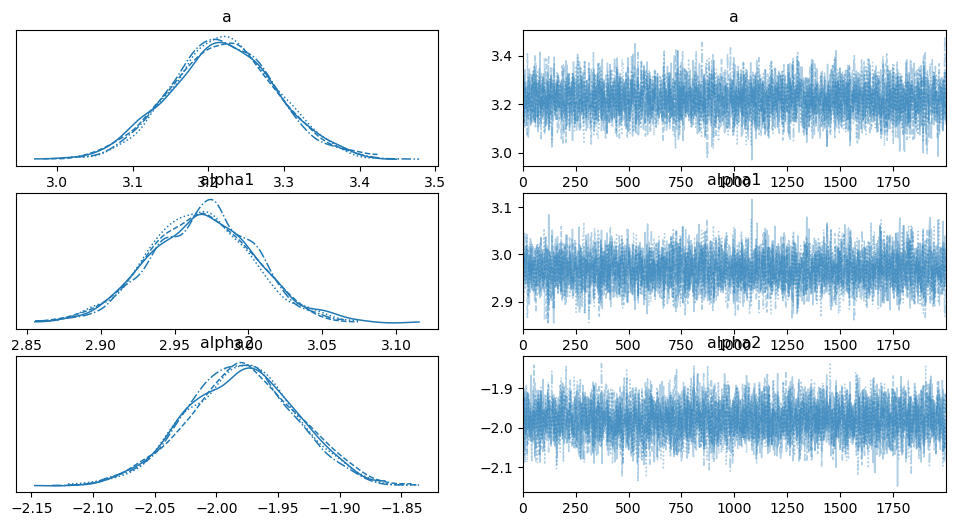

         mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
a       3.220  0.069   3.085    3.347      0.001    0.001    3417.0    3354.0   
alpha1  2.968  0.035   2.903    3.037      0.001    0.000    3531.0    3427.0   
alpha2 -1.980  0.044  -2.057   -1.893      0.001    0.001    3750.0    3580.0   

        r_hat  
a         1.0  
alpha1    1.0  
alpha2    1.0  


In [338]:
import matplotlib.pyplot as plt
az.plot_trace(trace)
plt.show()
summary=az.summary(trace)
print(summary)

In [342]:
import pymc as pm
import numpy as np
import arviz as az
import matplotlib.pyplot as plt

# 对数化变量
log_x1 = np.log(x1_obs)
log_x2 = np.log(x2_obs)
log_y = np.log(y_obs)
log_sigma_y = sigma_y / y_obs  # 误差传播到 log(y)

# 对数线性模型
with pm.Model() as log_linear_model:
    b = pm.Normal("b", mu=0, sigma=5)
    alpha1 = pm.Normal("alpha1", mu=0, sigma=5)
    alpha2 = pm.Normal("alpha2", mu=0, sigma=5)
    mu_log = b + alpha1 * log_x1 + alpha2 * log_x2

    mu = pm.math.exp(mu_log)
    
    # 观测误差
    sigma = pm.HalfNormal("sigma", sigma=1)  # 或使用sigma_y
    
    # 观测模型 - 对原始y建模
    Y = pm.Normal("Y", mu=mu, sigma=sigma, observed=y_obs)
    
    log_trace = pm.sample(2000, tune=2000, return_inferencedata=True)


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [b, alpha1, alpha2, sigma]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 11 seconds.


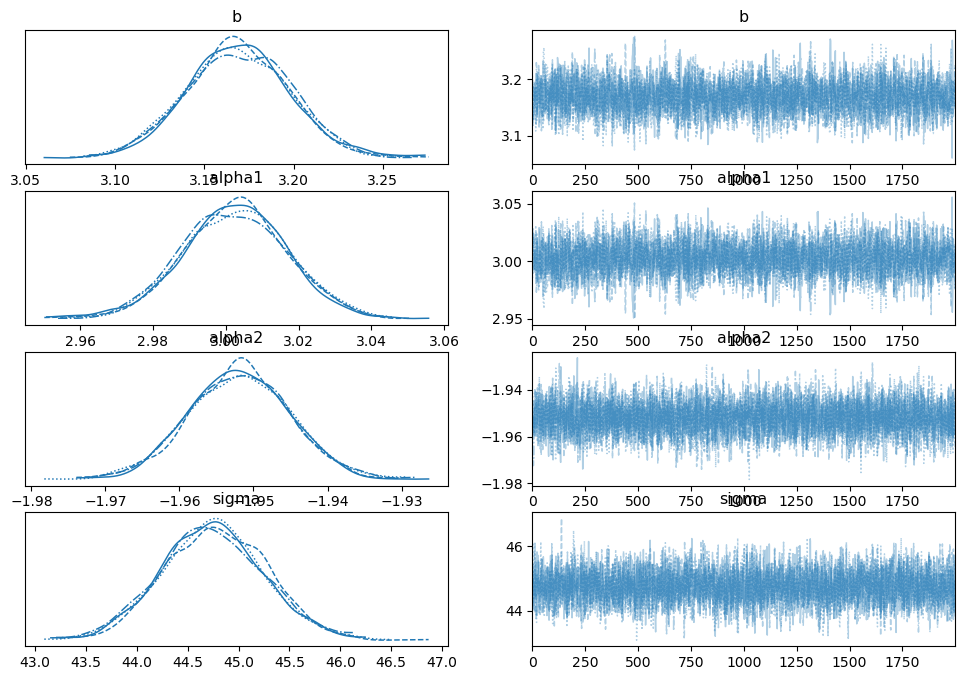

          mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
b        3.169  0.029   3.116    3.225      0.000    0.000    3384.0   
alpha1   3.003  0.014   2.976    3.030      0.000    0.000    3333.0   
alpha2  -1.952  0.007  -1.964   -1.939      0.000    0.000    4968.0   
sigma   44.748  0.501  43.836   45.719      0.008    0.005    4371.0   

        ess_tail  r_hat  
b         3581.0    1.0  
alpha1    3596.0    1.0  
alpha2    4358.0    1.0  
sigma     4006.0    1.0  


In [343]:
import matplotlib.pyplot as plt
az.plot_trace(log_trace)
plt.show()
summary1=az.summary(log_trace)
print(summary1)

/var/folders/5g/7cwc8n193kz9d4h5lc3ky_0c0000gn/T/ipykernel_21608/589973809.py:44: UserWarning: Glyph 35266 (\N{CJK UNIFIED IDEOGRAPH-89C2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5g/7cwc8n193kz9d4h5lc3ky_0c0000gn/T/ipykernel_21608/589973809.py:44: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5g/7cwc8n193kz9d4h5lc3ky_0c0000gn/T/ipykernel_21608/589973809.py:44: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5g/7cwc8n193kz9d4h5lc3ky_0c0000gn/T/ipykernel_21608/589973809.py:44: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5g/7cwc8n193kz9d4h5lc3ky_0c0000gn/T/ipykernel_21608/589973809.py:44: UserWarning: Glyph 38750 (\N{CJK UNIFIED IDEOGRAPH-975E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5g/7cwc8n193

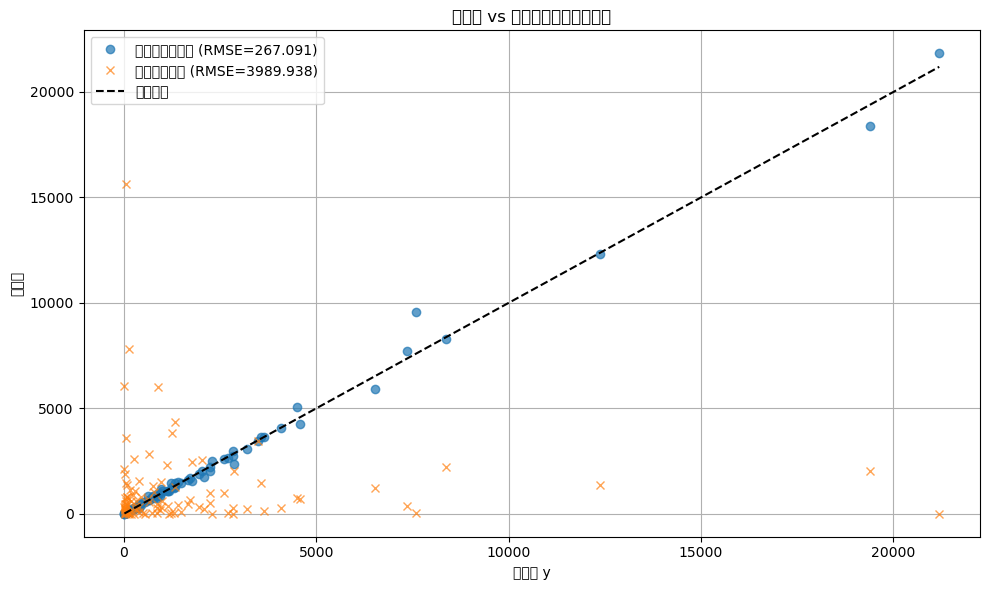

In [152]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# 从 posterior 中采样 100 次
samples = 100
a_samples = trace.posterior["a"].values.reshape(-1)[:samples]
alpha1_samples = trace.posterior["alpha1"].values.reshape(-1)[:samples]
alpha2_samples = trace.posterior["alpha2"].values.reshape(-1)[:samples]

b_samples = log_trace.posterior["b"].values.reshape(-1)[:samples]
alpha1_log_samples = log_trace.posterior["alpha1"].values.reshape(-1)[:samples]
alpha2_log_samples = log_trace.posterior["alpha2"].values.reshape(-1)[:samples]

# 计算非线性模型的预测平均
y_preds_nonlin = np.array([
    np.exp(a) * x1_obs**alpha1 * x2_obs**alpha2
    for a, alpha1, alpha2 in zip(a_samples, alpha1_samples, alpha2_samples)
])
y_pred_nonlin = y_preds_nonlin.mean(axis=0)

# 对数线性模型预测，转换回 y 空间后求平均
log_y_preds = np.array([
    b + alpha1 * log_x1 + alpha2 * log_x2
    for b, alpha1, alpha2 in zip(b_samples, alpha1_log_samples, alpha2_log_samples)
])
y_preds_loglin = np.exp(log_y_preds)
y_pred_loglin = y_preds_loglin.mean(axis=0)

# 计算 RMSE
rmse_nonlin = np.sqrt(mean_squared_error(y_obs, y_pred_nonlin))
rmse_loglin = np.sqrt(mean_squared_error(y_obs, y_pred_loglin))

# 可视化
plt.figure(figsize=(10, 6))
plt.plot(y_obs, y_pred_nonlin, "o", label=f"非线性模型预测 (RMSE={rmse_nonlin:.3f})", alpha=0.7)
plt.plot(y_obs, y_pred_loglin, "x", label=f"对数线性预测 (RMSE={rmse_loglin:.3f})", alpha=0.7)
plt.plot([min(y_obs), max(y_obs)], [min(y_obs), max(y_obs)], "k--", label="理想预测")
plt.xlabel("观测值 y")
plt.ylabel("预测值")
plt.legend()
plt.title("非线性 vs 对数线性模型预测对比")
plt.grid(True)
plt.tight_layout()
plt.show()


In [63]:

print(f"MSE（非线性模型）: {rmse_nonlin:.4f}")
print(f"MSE（对数线性模型）: {rmse_loglin:.4f}")


MSE（非线性模型）: 224.5119
MSE（对数线性模型）: 269.6719


In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [109]:
file_path = 'LH_metal_DB_v1.12.csv'  # 替换为你的文件路径
df = pd.read_csv(file_path)
df.loc[:, 'TOK'] = df['TOK'].str.strip()
df['IP']=df['IP'].abs()/1000000
df['BT']=df['BT'].abs()
df['PLTH']=df['PLTH']/1000000
df['NEL']=df['NEL']/1e19


df.loc[:, 'TOK'] = df['TOK'].str.strip()

reference_dict = {
    1.00:  "Hydrogen",
    2.00:  "Deuterium",
    2.50:  "Deuterium and tritium",
    3.00:  "3He or tritium",
    4.00:  "4He",
    14.01: "Nitrogen"
}

# 定义一个函数，用来根据某一观测值PGASA，返回对应的分类名称
def categorize_pgasa(value, ref_dict, tolerance=0.2):
    """
    value: 待分类的数值
    ref_dict: {参考值: 分类名称}
    tolerance: 容忍度，即 |value - 参考值| 需小于等于该值才视为同一类
    """
    # 1) 找到离 value 最近的参考值
    closest_ref = min(ref_dict.keys(), key=lambda x: abs(x - value))
    # 2) 判断两者差值是否在容忍度以内
    if abs(closest_ref - value) <= tolerance:
        return ref_dict[closest_ref]
    else:
        return np.nan  # 或者 "Other"

# 将 categorize_pgasa 应用于 df["PGASA"] 列，生成新的分类列
df["Category"] = df["PGASA"].apply(lambda x: categorize_pgasa(x, reference_dict, tolerance=0.1))

# 如果需要查看分类结果
print(df)



# 假设 subset1 是你的数据框
colors = df['SELEC2024'].map({1: 'red', 0: 'blue'})
x = df['NEL']
y = df['PLTH']
bt = df['BT'].abs()
ip= df['IP']

# 分类 BT 值
#subset2_2 = df[(ip < 2.6) & (ip >=2.4)&(bt < 3.2) & (bt >=2.8)& (df['Category'] == 'Deuterium')& (df['DIVCON'] == 'VT')]
#df = df.drop(subset2_2.index)
print(df)
import statsmodels.api as sm

# 指定你想在新 DataFrame 中包含的列
columns_to_include = ['TOK', 'SPLASMA','BT','IP','RGEO','PLTH','NEL','PGASA',"DIVCON"]
new_df = df[df['SELEC2024'] == 1][columns_to_include].copy()
mu0 = 4 * np.pi * 1e-7

new_df['BP']=1000000*(mu0 * new_df['IP']) / (new_df['SPLASMA']/(2 * np.pi * new_df['RGEO']))

new_df['PLTH/S/2']=new_df['PLTH']/(new_df['SPLASMA']*2)
#new_df['PLTH/S/2']=new_df['PLTH']
# 显示新 DataFrame
print("New DataFrame:")
print(new_df)


columns_to_include_for_regre = ['BP','PLTH/S/2','NEL','PGASA']
unique_divcon = new_df['DIVCON'].unique()

# 2. 向原始 DataFrame 添加新列
for divcon_type in unique_divcon:
    new_df[divcon_type] = (new_df['DIVCON'] == divcon_type).astype(int)
multi_df = new_df[columns_to_include_for_regre].copy()
multi_df = multi_df.apply(np.log)
x = multi_df[['BP','NEL','PGASA']] 
#x = multi_df[['BT','NEL','PGASA']]
x[unique_divcon] = new_df[unique_divcon]
#x['Xp'] = x[['Xptref','Xpthigh','Xptin']].max(axis=1)
#x.drop(['STANDARD'], axis=1, inplace=True)
x.drop(['Xptref','Xpthigh','Xptin'], axis=1, inplace=True)
x['CV'] = x[['CORNER','VT']].max(axis=1)
x.drop(['V5E','V5C','HT3R','STANDARD','V5','CORNER','VT',' VERTPLT'], axis=1, inplace=True)
X_with_intercept = sm.add_constant(x)
y=multi_df["PLTH/S/2"]
model = sm.OLS(y, X_with_intercept)
results = model.fit()

# 打印详细统计结果
print(results.summary())

# 输出系数和标准误差
coefficients = results.params
std_errors = results.bse

labels = X_with_intercept.columns  # 获取变量名
for label, coef, std_err in zip(labels, coefficients, std_errors):
    print(f"{label}: {coef:.3f} ± {std_err:.3f}")
    # 打印 RMSE
y_pred = results.predict(X_with_intercept)  # 预测值
rmse = np.sqrt(np.mean((y - y_pred) ** 2))  # 计算 RMSE

print(f"RMSE: {rmse:.3f}")
# 获取 90% 置信区间
conf_int_90 = results.conf_int(alpha=0.1)


print("\n90% 置信区间：\n", conf_int_90)
new_df[columns_to_include_for_regre]
y=np.exp(y)

      TOK        SHOT      TIME PHASE  PGASA      RGEO      AMIN    KAPPA  \
0    CMOD  1050428004   0.63461    LH  2.000  0.672389  0.216421  1.69737   
1    CMOD  1050428007   0.66603    LH  2.000  0.670773  0.217660  1.67073   
2    CMOD  1050621015   0.91039    LH  2.000  0.672785  0.217388  1.67962   
3    CMOD  1050621029   0.85420    LH  2.000  0.670869  0.217080  1.69789   
4    CMOD  1050623008   0.80070    LH  2.000  0.678764  0.213690  1.44202   
..    ...         ...       ...   ...    ...       ...       ...      ...   
685   JET       90527  50.99500    LH  1.962  2.900090  0.933780  1.66731   
686   JET       90528  55.16500    LH  1.916  2.901440  0.933319  1.66831   
687   JET       90737  54.56500    LH  1.940  2.901330  0.934255  1.66599   
688   JET       90738  54.46500    LH  1.961  2.898400  0.937640  1.65848   
689   JET       90742  52.16500    LH  1.983  2.900930  0.933565  1.66813   

       SPLASMA CONFIG  ...       PL     PLTH    PFLOSS PRADCORE    DIVCON  

In [108]:
multi_df

,BP,PLTH/S/2,NEL,PGASA
0,-0.405618,-1.869197,2.980619,0.693147
2,-0.783827,-2.337522,2.939162,0.693147
3,-0.309062,-2.382742,2.785011,0.693147
4,-0.607297,-2.013214,3.091042,0.693147
5,-0.639845,-2.002391,3.068053,0.693147
...,...,...,...,...
679,-0.899797,-3.562810,1.294727,0.653366
680,-0.649343,-3.632794,1.187843,0.654926
683,-1.025837,-3.622479,1.169381,0.649718
684,-0.766807,-3.417765,1.181727,0.643957


In [133]:

# Step 1: Generate simulated data
np.random.seed(42)
N = 3000  # Number of samples
D = 6  # Number of predictors


# Step 2: Define the PyMC model
with pm.Model() as model:
    # Priors
    # Beta for regression coefficients, grouped into classes
    alpha = pm.HalfNormal("alpha", sigma=8.0)  # Dirichlet prior concentration parameter
    #alpha=1
    p = pm.Dirichlet("p", a=pm.math.ones(30) * alpha, shape=30)  # Class probabilities
 #10 0 1 2 3 4 
    S = pm.Categorical("S", p=p, shape=D)# bp=nel shape  1 1 1  # Class assignment for predictors (0-9)
    #[1 3 5 7 9]
    eta = pm.InverseGamma("eta", alpha=4, beta=4)  # Variance for beta_m
    mu_0=pm.Normal("beta_ori",mu=0,sigma=1)
    beta_m = pm.Normal("beta_m", mu=mu_0, sigma=pm.math.sqrt(eta), shape=30)  # Regression coefficients for each class
    
    # Ensure S only indexes valid categories of beta_m
    beta = pm.Deterministic("beta", beta_m[S])  # Map beta based on S
    
    # Sparsity indicator gamma
    #pi = pm.Beta("pi", alpha=1, beta=1)  # Probability of gamma=1
    #gamma_prev = pm.Bernoulli("gamma_prev", p=0.5, shape=D)  # 初始值
    #rho = 0.3  # 控制gamma的平稳性（越接近1越稳定）
    #gamma = pm.Bernoulli("gamma", p=rho * gamma_prev + (1 - rho) * pi, shape=D)
    
    #gamma = pm.Bernoulli("gamma", p=pi, shape=D)

    # Noise variance (sigma^2)
    sigma2 = pm.InverseGamma("sigma2", alpha=4, beta=0.5)  # Prior for noise variance

    # Observed data likelihood
    mu1 = pm.math.dot(X_with_intercept, beta )  # Predicted mean
    f=pm.math.exp(mu1)
    
    
    # 误差传播：df/dx1 和 df/dx2
    #sigma_X = pm.InverseGamma("sigma_X",  alpha=4, beta=1)
    
    beta_vars = beta[1:]     
    #gamma_vars = gamma[1:4]     
    

    # 误差传播 df/dxi
    X_shared = pm.Data("X_shared", X_with_intercept.iloc[:, 1:].values)
    sigma_X = pm.math.exp(X_shared)*0.01

    df_dxi = f[:, None] * (beta_vars) / (pm.math.exp(X_shared) )  
    
    
    
    # 有效误差
    propagated_error2 = pm.math.sum((df_dxi**2) * sigma_X**2, axis=1)
    sigma_eff = pm.math.sqrt(sigma2 + propagated_error2 )

    y_obs = pm.Normal("y_obs", mu=f, sigma=sigma_eff, observed=y)
    
    
    

    # Inference
    
    trace = pm.sample(N, tune=500, chains=4,step=pm.NUTS(target_accept=0.95), return_inferencedata=True)


# Step 3: Analyze and visualize the results
az.plot_trace(trace, var_names=["beta","sigma_X","sigma2", "eta", "beta_ori","pi", "p"])
plt.show()
summary=az.summary(trace, var_names=["beta", "sigma_X", "sigma2", "eta","beta_ori", "pi", "p"])
print(summary)

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [alpha, p, eta, beta_ori, beta_m, sigma2]
>CategoricalGibbsMetropolis: [S]


Output()

Sampling 4 chains for 500 tune and 3_000 draw iterations (2_000 + 12_000 draws total) took 385 seconds.
There were 3852 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


KeyError: 'var names: "[\'sigma_X\' \'pi\'] are not present" in dataset'

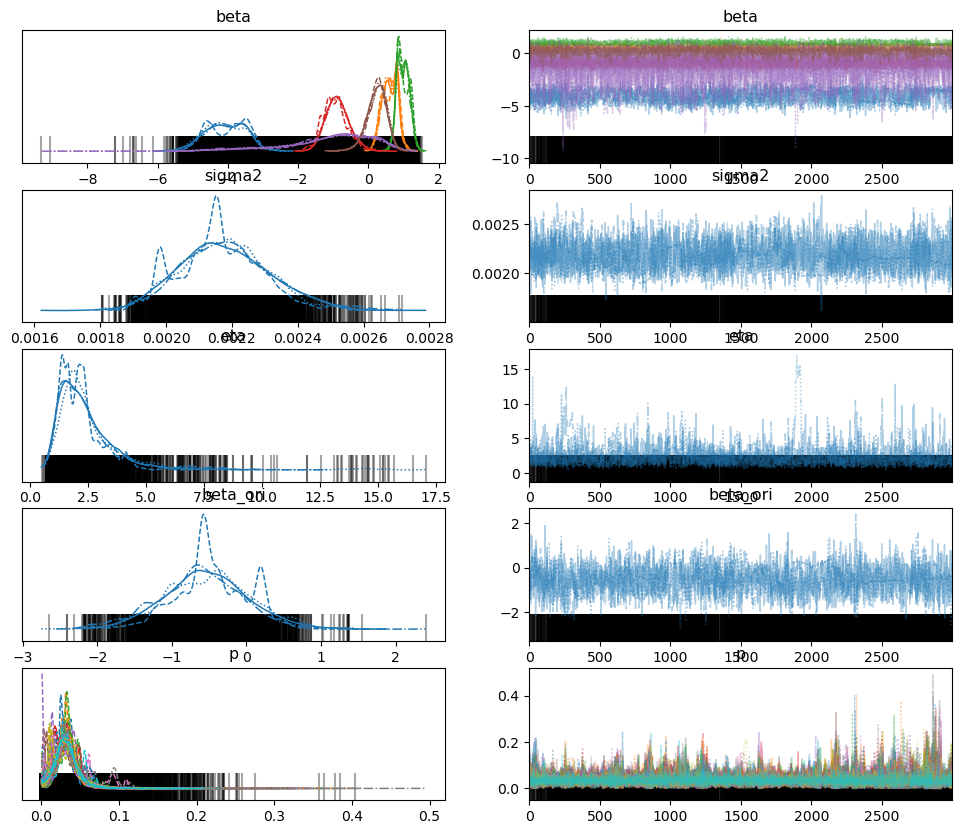

           mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
beta[0]  -4.066  0.575  -5.076   -3.089      0.030    0.021     386.0   
beta[1]   0.617  0.216   0.203    0.959      0.011    0.008     394.0   
beta[2]   0.992  0.173   0.715    1.324      0.009    0.006     414.0   
beta[3]  -0.900  0.349  -1.525   -0.226      0.014    0.011     576.0   
beta[4]  -1.123  1.308  -3.762    0.870      0.024    0.019    3825.0   
beta[5]   0.240  0.281  -0.287    0.737      0.008    0.005    1322.0   
sigma2    0.002  0.000   0.002    0.002      0.000    0.000     593.0   
eta       2.385  1.395   0.716    4.483      0.074    0.055     448.0   
beta_ori -0.530  0.562  -1.591    0.531      0.024    0.018     546.0   
p[0]      0.033  0.017   0.002    0.060      0.000    0.000     875.0   
p[1]      0.035  0.018   0.004    0.063      0.001    0.000     629.0   
p[2]      0.033  0.017   0.004    0.064      0.001    0.000     718.0   
p[3]      0.034  0.018   0.002    0.061      0.001 

In [134]:
az.plot_trace(trace, var_names=["beta","sigma2", "eta", "beta_ori", "p"])
plt.show()
summary=az.summary(trace, var_names=["beta", "sigma2", "eta","beta_ori", "p"])
print(summary)

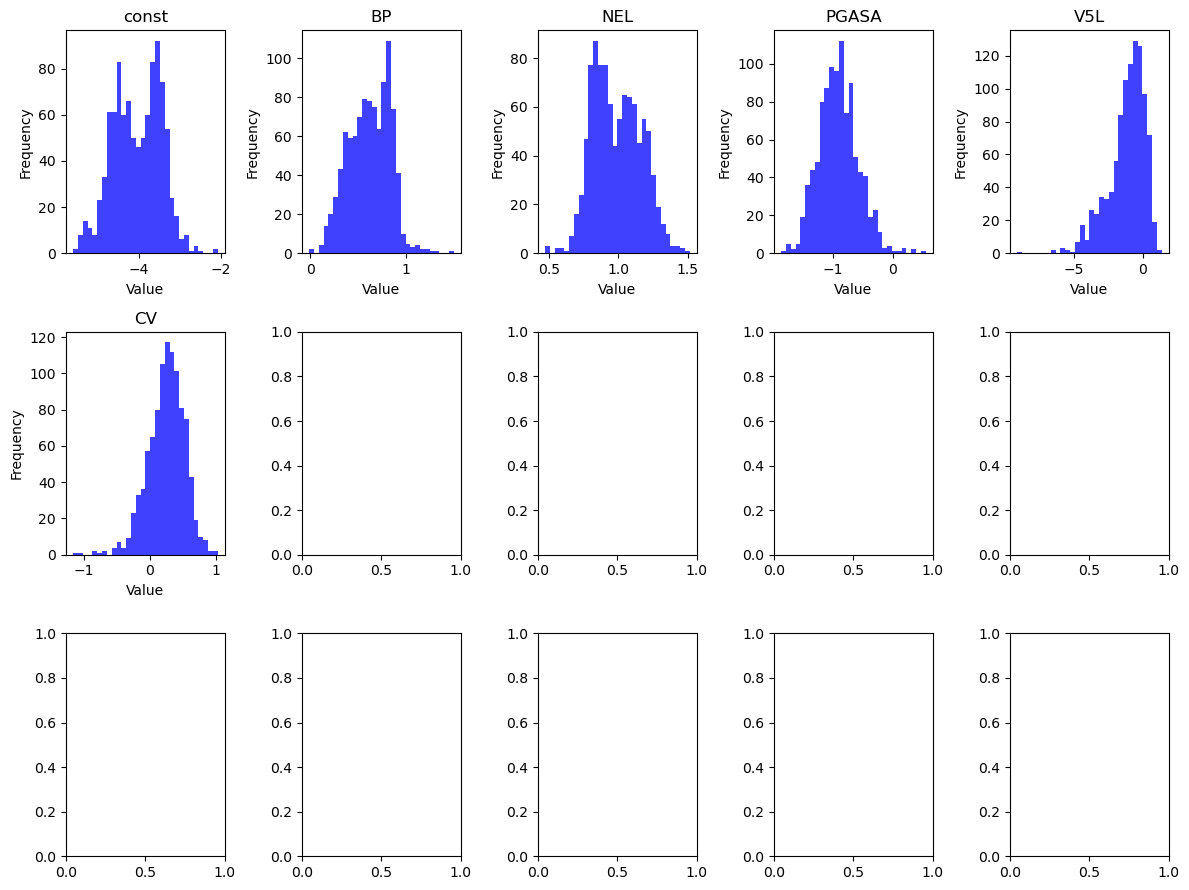

[-4.048836    0.6202027   0.9883561  -0.9104326  -1.16031502  0.2458541 ]
[ 9.028 15.083 13.324 14.907 13.8   14.289]
1000 samples' R² values=: 0.9492


In [147]:
# 从后验中随机抽取 10 个样本
num_samples = 1000
posterior_indices = np.random.choice(
    trace.posterior["beta"].stack(samples=["chain", "draw"]).shape[1], 
    size=num_samples, 
    replace=False
)

# 定义新数据
 # 新数据 (10 个样本)

# 存储预测结果
beta_new_look = []
predictions = []
S_new = []
gamma_new=[]
for idx in posterior_indices:
    beta_sample = trace.posterior["beta"].stack(samples=["chain", "draw"]).values[:, idx]
    #gamma_sample = trace.posterior["gamma"].stack(samples=["chain", "draw"]).values[:, idx]
    S_sample = trace.posterior["S"].stack(samples=["chain", "draw"]).values[:, idx]
    sigma_sample = np.sqrt(trace.posterior["sigma2"].stack(samples=["chain", "draw"]).values[idx])
    #gamma_binary = (gamma_post_mean > 0.5).astype(int)
    # 计算预测值
    mu_pred = X_with_intercept @ (beta_sample )  # 预测均值
    y_pred = np.random.normal(mu_pred, sigma_sample, size=X_with_intercept.shape[0])  # 从预测分布采样
    S_new.append(beta_sample)
    beta_new_look.append(S_sample)
    #gamma_new.append(gamma_sample)
    predictions.append(y_pred)
S_new1 = np.array(S_new)
#gamma_new = np.array(gamma_new)
fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(12, 9))
axes = axes.flatten()

for i in range(6):
    ax = axes[i]
    # 只考虑 gamma 为 1 的情况
    #filtered_beta = S_new1[:, i][gamma_new[:, i] == 1]
    filtered_beta = S_new1[:, i]
    ax.hist(filtered_beta, bins=30, alpha=0.75, color='blue')
    ax.set_title(f'{X_with_intercept.columns[i]}')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('distribution.png', format='png', dpi=300, transparent=True)
plt.show()
S_mean_new = np.array(S_new).mean(axis=0)
beta_new_look_new = np.array(beta_new_look).mean(axis=0)
#gamma_mean = np.array(gamma_new).mean(axis=0) 
#gamma_binary = (gamma_mean > 0.5).astype(int)
#print(gamma_mean)

predictions = np.exp(np.array(predictions).T)  
pred_mean = predictions.mean(axis=1) 
print(S_mean_new)
print(beta_new_look_new)
SS_res = np.sum((pred_mean - y) ** 2)
SS_tot = np.sum((y - np.mean(y)) ** 2)
R_squared = 1 - (SS_res / SS_tot)
print(f"1000 samples' R² values=: {R_squared:.4f}")

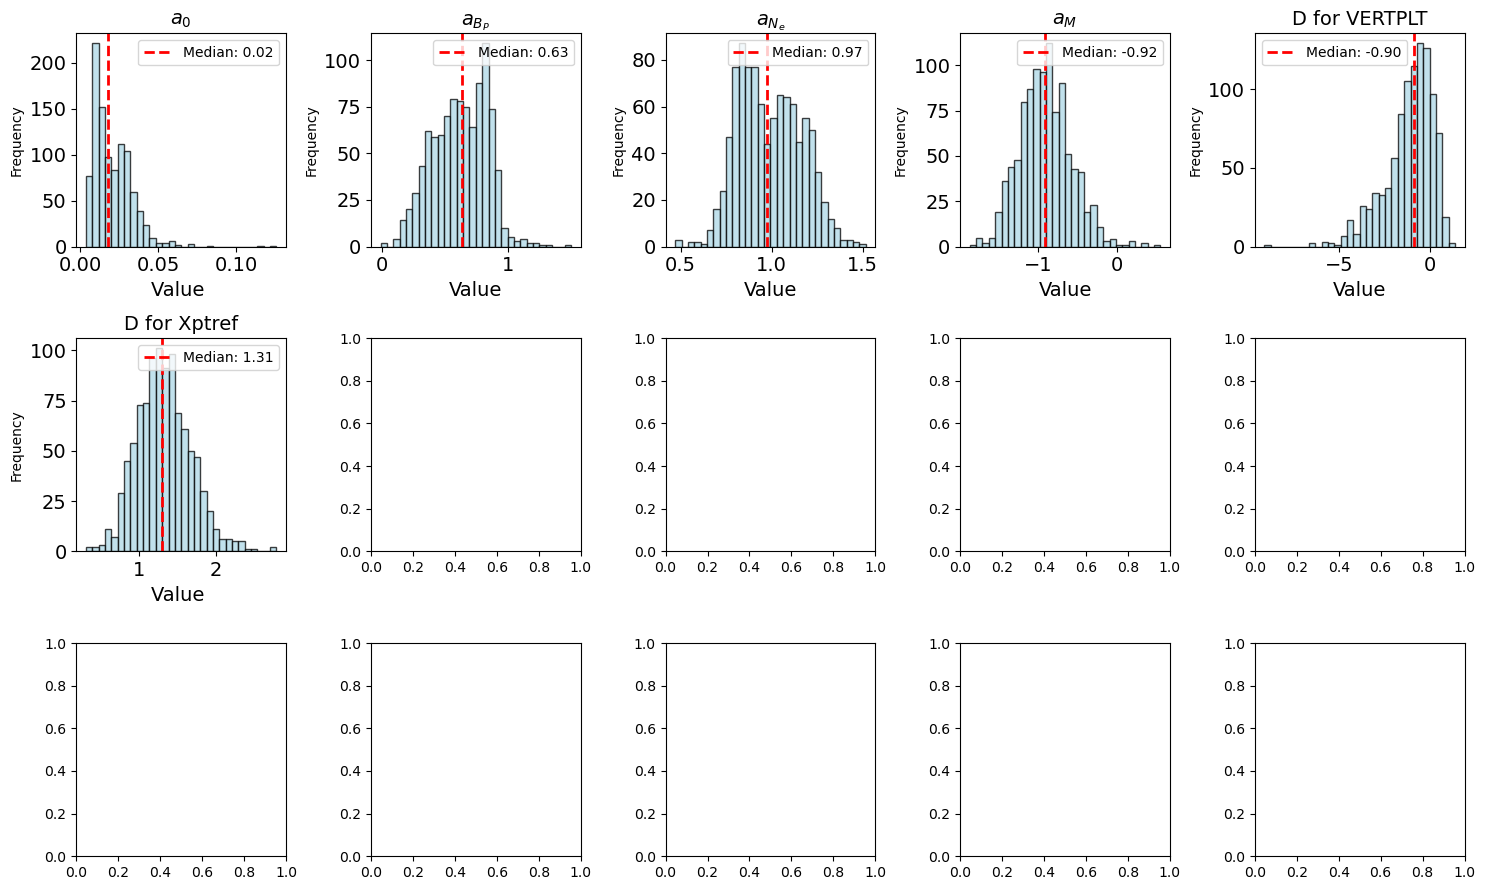

[-4.048836    0.6202027   0.9883561  -0.9104326  -1.16031502  0.2458541 ]
[ 9.028 15.083 13.324 14.907 13.8   14.289]
(483,)
1000 samples' RMSE: 0.2055


In [148]:
import numpy as np
import matplotlib.pyplot as plt
titles = ["$a_0$", "$a_{B_P}$", "$a_{N_e}$", "$a_{M}$", "D for VERTPLT", "D for Xptref", "D for Xpthigh", "D for Xptin", "D for V5", "D for CORNER", "D for VT", "D for V5L", "D for V5E", "D for V5C", "D for HT3R"]
S_new1 = np.array(S_new)  # 转换为 NumPy 数组
#gamma_new = np.array(gamma_new)
D=6
# 绘制直方图
fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(15, 9))
axes = axes.flatten()

for i in range(D):
    if i ==12 or i ==13:
        continue
    else:
        ax = axes[i]


        # 只有第一张 (i=0) 和最后一张 (i=D-1) 需要 exp 变换
        if i == 0 or i in [ 5]:

            filtered_beta = np.exp(S_new1[:, i])  # 只对特定索引应用 exp
            xlabel_text = 'Value '
        else:
            filtered_beta = S_new1[:, i]
            xlabel_text = 'Value'

        # 计算中位数
        median_value = np.median(filtered_beta)

        # 绘制直方图（颜色设为浅蓝）
        ax.hist(filtered_beta, bins=30, alpha=0.75, color='lightblue', edgecolor='black')

        # 标出中位数
        ax.axvline(median_value, color='red', linestyle='dashed', linewidth=2, label=f'Median: {median_value:.2f}')
        ax.legend()

        # 设置标题和标签
        #ax.set_title(f'{X_with_intercept.columns[i]}')
        ax.set_title(titles[i], fontsize=14)
        ax.set_xlabel(xlabel_text, fontsize=14)
        ax.tick_params(axis='both', which='major', labelsize=14)
        ax.set_ylabel('Frequency')

plt.tight_layout()
#plt.savefig('distribution_exp_all_config_median.png', format='png', dpi=300, transparent=True)
plt.show()

# 计算均值
S_mean_new = S_new1.mean(axis=0)
beta_new_look_new = np.array(beta_new_look).mean(axis=0)  
#gamma_mean = np.array(gamma_new).mean(axis=0) 
#gamma_binary = (gamma_mean > 0.5).astype(int)

#print(gamma_mean)
print(S_mean_new)
print(beta_new_look_new)

#predictions = np.array(predictions).T  
#pred_mean = predictions.mean(axis=1) 
'''SS_res = np.sum((pred_mean - y) ** 2)
SS_tot = np.sum((y - np.mean(y)) ** 2)
R_squared = 1 - (SS_res / SS_tot)

print(f"1000 samples' R² values=: {R_squared:.4f}")'''
from sklearn.metrics import mean_squared_error
pred_mean = predictions.mean(axis=1)  # 在采样维度上取均值，使得 pred_mean 变为 (483,)
print(pred_mean.shape)
rmse = np.sqrt(mean_squared_error(np.log(y+0.0001), np.log(pred_mean+0.0001)))
print(f"1000 samples' RMSE: {rmse:.4f}")

In [145]:
y

array([0.15424748, 0.09656667, 0.09229715, 0.13355873, 0.13501213,
       0.12633432, 0.139425  , 0.13630756, 0.15517897, 0.11576071,
       0.18584386, 0.14872209, 0.15231362, 0.16098383, 0.17656194,
       0.27034491, 0.23803664, 0.23600867, 0.09941677, 0.10585429,
       0.09219678, 0.10776157, 0.10404057, 0.20214006, 0.11507368,
       0.11151735, 0.13816255, 0.1800933 , 0.14719197, 0.16363641,
       0.18767516, 0.16935553, 0.1704408 , 0.19867996, 0.12707296,
       0.12598312, 0.10812847, 0.10911106, 0.0997961 , 0.13575027,
       0.10285777, 0.10213168, 0.10872027, 0.18370212, 0.14607492,
       0.10536974, 0.17963078, 0.14421636, 0.12792421, 0.12158713,
       0.1168123 , 0.12325826, 0.18686194, 0.15766927, 0.12323488,
       0.1350199 , 0.21431329, 0.21616967, 0.2652627 , 0.01862657,
       0.01851021, 0.01454139, 0.01688809, 0.01463964, 0.01788909,
       0.01744186, 0.02508921, 0.01587302, 0.01406074, 0.01462646,
       0.0184158 , 0.01985721, 0.01782531, 0.0157871 , 0.01810

In [348]:
import pymc as pm
import numpy as np
import arviz as az

file_path = 'LH_metal_DB_v1.12.csv'  # 替换为你的文件路径
df = pd.read_csv(file_path)
df.loc[:, 'TOK'] = df['TOK'].str.strip()
df['IP']=df['IP'].abs()/1000000
df['BT']=df['BT'].abs()
df['PLTH']=df['PLTH']/1000000
df['NEL']=df['NEL']/1e19


df.loc[:, 'TOK'] = df['TOK'].str.strip()

reference_dict = {
    1.00:  "Hydrogen",
    2.00:  "Deuterium",
    2.50:  "Deuterium and tritium",
    3.00:  "3He or tritium",
    4.00:  "4He",
    14.01: "Nitrogen"
}

# 定义一个函数，用来根据某一观测值PGASA，返回对应的分类名称
def categorize_pgasa(value, ref_dict, tolerance=0.2):
    """
    value: 待分类的数值
    ref_dict: {参考值: 分类名称}
    tolerance: 容忍度，即 |value - 参考值| 需小于等于该值才视为同一类
    """
    # 1) 找到离 value 最近的参考值
    closest_ref = min(ref_dict.keys(), key=lambda x: abs(x - value))
    # 2) 判断两者差值是否在容忍度以内
    if abs(closest_ref - value) <= tolerance:
        return ref_dict[closest_ref]
    else:
        return np.nan  # 或者 "Other"

# 将 categorize_pgasa 应用于 df["PGASA"] 列，生成新的分类列
df["Category"] = df["PGASA"].apply(lambda x: categorize_pgasa(x, reference_dict, tolerance=0.1))

# 如果需要查看分类结果
print(df)



# 假设 subset1 是你的数据框
colors = df['SELEC2024'].map({1: 'red', 0: 'blue'})
x = df['NEL']
y = df['PLTH']
bt = df['BT'].abs()
ip= df['IP']

# 分类 BT 值
#subset2_2 = df[(ip < 2.6) & (ip >=2.4)&(bt < 3.2) & (bt >=2.8)& (df['Category'] == 'Deuterium')& (df['DIVCON'] == 'VT')]
#df = df.drop(subset2_2.index)
print(df)
import statsmodels.api as sm

# 指定你想在新 DataFrame 中包含的列
columns_to_include = ['TOK', 'SPLASMA','BT','IP','RGEO','PLTH','NEL','PGASA',"DIVCON"]
new_df = df[df['SELEC2024'] == 1][columns_to_include].copy()
mu0 = 4 * np.pi * 1e-7

new_df['BP']=1000000*(mu0 * new_df['IP']) / (new_df['SPLASMA']/(2 * np.pi * new_df['RGEO']))

new_df['PLTH/S/2']=new_df['PLTH']/(new_df['SPLASMA']*2)
#new_df['PLTH/S/2']=new_df['PLTH']
# 显示新 DataFrame
print("New DataFrame:")
print(new_df)


columns_to_include_for_regre = ['BP','PLTH/S/2','NEL','PGASA']
unique_divcon = new_df['DIVCON'].unique()


for divcon_type in unique_divcon:
    new_df[divcon_type] = (new_df['DIVCON'] == divcon_type).astype(int)
multi_df = new_df[columns_to_include_for_regre].copy()

x = multi_df[['BP','NEL','PGASA']] 

x[unique_divcon] = new_df[unique_divcon]
x.drop(['Xptref','Xpthigh','Xptin'], axis=1, inplace=True)
x['CV'] = x[['CORNER','VT']].max(axis=1)
x.drop(['V5E','V5C','HT3R','STANDARD','V5','CORNER','VT',' VERTPLT'], axis=1, inplace=True)

y=multi_df["PLTH/S/2"]

# 各变量的误差

sigma_x1 = 0.05 * x['BP']
sigma_x2 = 0.05 * x['NEL']
sigma_x3 = 0.05 * x['PGASA']

with pm.Model() as model:
    # 先验
    x_BP = pm.Data("x_BP", x['BP'].values)
    x_NEL = pm.Data("x_NEL", x['NEL'].values)
    x_PGASA = pm.Data("x_PGASA", x['PGASA'].values)
    x_V5L = pm.Data("x_V5L", x['V5L'].values)
    x_CV = pm.Data("x_CV", x['CV'].values)
    
    a = pm.Normal("a", mu=0, sigma=5)
    sigma_y=pm.Normal("sigma1", mu=0, sigma=1)
    alpha1 = pm.Normal("alpha1", mu=0, sigma=5)
    alpha2 = pm.Normal("alpha2", mu=0, sigma=5)
    alpha3 = pm.Normal("alpha3", mu=0, sigma=5)
    alpha4 = pm.Normal("alpha4", mu=0, sigma=5)
    alpha5 = pm.Normal("alpha5", mu=0, sigma=5)
    a1=pm.math.exp(a)
    # 误差传播：df/dx1 和 df/dx2
    f = a1 * x_BP**alpha1 * x_NEL**alpha2* x_PGASA**alpha3* pm.math.exp(x_V5L)**alpha4* pm.math.exp(x_CV)**alpha5
    df_dx1 = f * alpha1 / x_BP
    df_dx2 = f * alpha2 / x_NEL
    df_dx3 = f * alpha3 / x_PGASA
    
    # 有效误差 σ_eff^2 = σ_y^2 + (df/dx1)^2 * σ_x1^2 + (df/dx2)^2 * σ_x2^2
    sigma_eff2 = sigma_y**2 + (df_dx1**2) * sigma_x1**2 + (df_dx2**2) * sigma_x2**2+ (df_dx3**2) * sigma_x3**2
    sigma_eff = pm.math.sqrt(sigma_eff2)
    
    # 似然函数
    Y = pm.Normal("Y", mu=f, sigma=sigma_eff, observed=y)
    
    # 采样
    trace = pm.sample(2000, tune=2000, return_inferencedata=True)


      TOK        SHOT      TIME PHASE  PGASA      RGEO      AMIN    KAPPA  \
0    CMOD  1050428004   0.63461    LH  2.000  0.672389  0.216421  1.69737   
1    CMOD  1050428007   0.66603    LH  2.000  0.670773  0.217660  1.67073   
2    CMOD  1050621015   0.91039    LH  2.000  0.672785  0.217388  1.67962   
3    CMOD  1050621029   0.85420    LH  2.000  0.670869  0.217080  1.69789   
4    CMOD  1050623008   0.80070    LH  2.000  0.678764  0.213690  1.44202   
..    ...         ...       ...   ...    ...       ...       ...      ...   
685   JET       90527  50.99500    LH  1.962  2.900090  0.933780  1.66731   
686   JET       90528  55.16500    LH  1.916  2.901440  0.933319  1.66831   
687   JET       90737  54.56500    LH  1.940  2.901330  0.934255  1.66599   
688   JET       90738  54.46500    LH  1.961  2.898400  0.937640  1.65848   
689   JET       90742  52.16500    LH  1.983  2.900930  0.933565  1.66813   

       SPLASMA CONFIG  ...       PL     PLTH    PFLOSS PRADCORE    DIVCON  

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, sigma1, alpha1, alpha2, alpha3, alpha4, alpha5]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 27 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


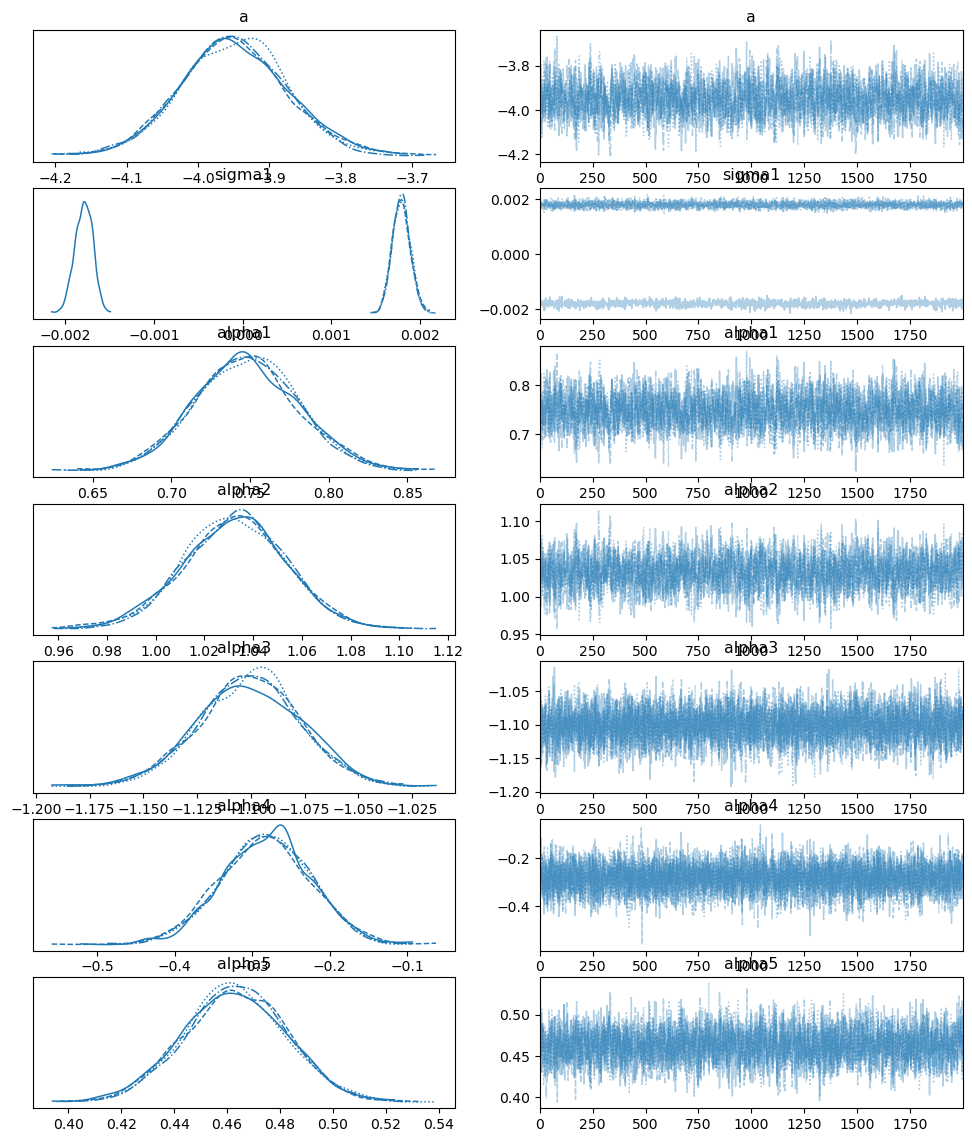

         mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
a      -3.950  0.074  -4.082   -3.803      0.002    0.001    1808.0    2645.0   
sigma1  0.001  0.002  -0.002    0.002      0.001    0.001       7.0      28.0   
alpha1  0.748  0.033   0.687    0.812      0.001    0.001    1971.0    3001.0   
alpha2  1.032  0.021   0.995    1.074      0.000    0.000    1993.0    3015.0   
alpha3 -1.101  0.024  -1.146   -1.056      0.000    0.000    5107.0    5294.0   
alpha4 -0.283  0.058  -0.388   -0.172      0.001    0.000    6830.0    5071.0   
alpha5  0.463  0.019   0.427    0.499      0.000    0.000    2680.0    4225.0   

        r_hat  
a        1.00  
sigma1   1.53  
alpha1   1.00  
alpha2   1.00  
alpha3   1.00  
alpha4   1.00  
alpha5   1.00  


In [12]:
import matplotlib.pyplot as plt
az.plot_trace(trace)
plt.show()
summary=az.summary(trace)
print(summary)

In [351]:

trace.to_netcdf("non_linear_trace.nc")



'non_linear_trace.nc'

In [2]:
# 读取存储的 trace

import arviz as az

trace = az.from_netcdf("non_linear_trace.nc")

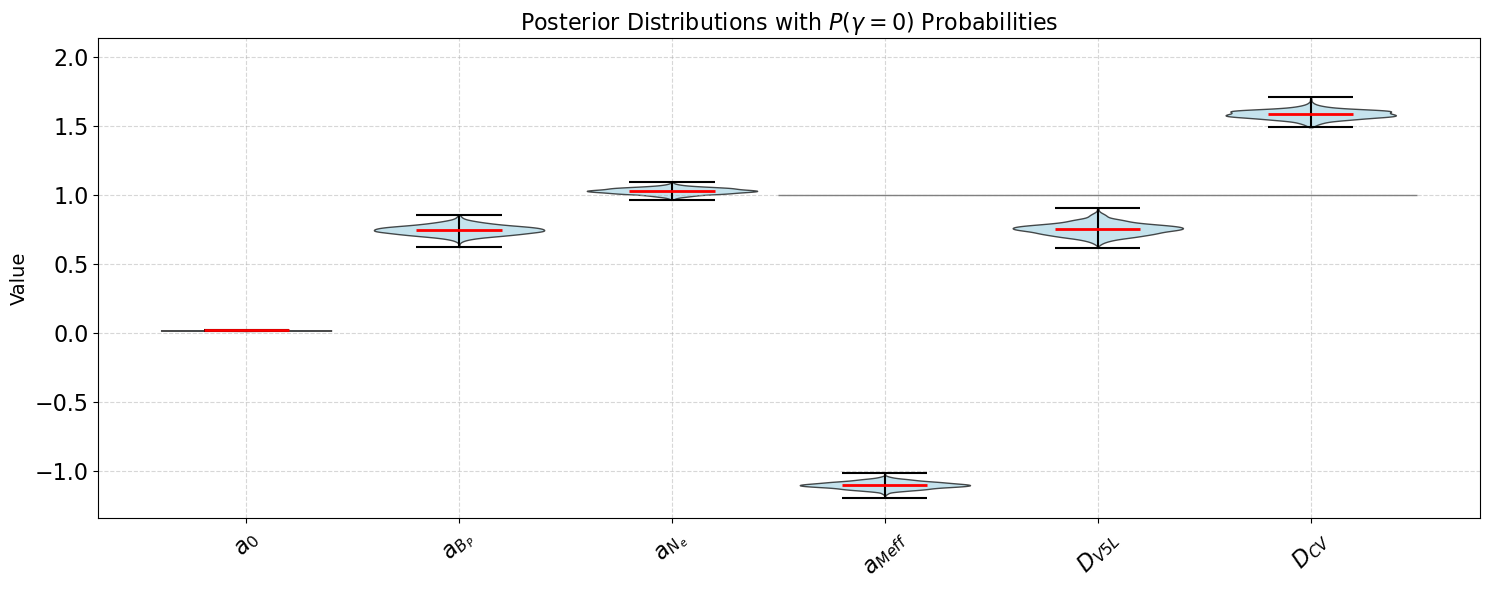

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import arviz as az

# 从 trace 中提取 1000 次后验样本
posterior_samples = az.extract(trace, num_samples=1000)
# 转为 NumPy 数组格式（确保一致性）
posterior_array = {k: np.array(v) for k, v in posterior_samples.items()}

# 修改后的变量名称列表（用于x轴标签）
titles = ["$a_0$","sigma", "$a_{B_P}$", "$a_{N_e}$", "$a_{Meff}$", 
          "$D_{V5L}$", "$D_{CV}$"]

D = 7  # 变量总数

# 选择哪些变量进行对数变换
log_transform_indices = [0, 5,6, 6, 7, 8, 9, 10, 11, 12, 13, 14]

# 提取后验样本并处理
data = []
filtered_indices = []
gamma_prob_0 = []

for i in range(D):
    varname = list(posterior_array.keys())[i]
    samples = posterior_array[varname]

    # 假设 gamma 的值在 trace 中有类似 gamma_XXX 的变量
    gamma_varname = f'gamma_{varname}' if f'gamma_{varname}' in posterior_array else None

    if i == 1 or i == 13:
        continue  # 排除变量 D_{V5E}, D_{V5C}
    
    filtered_indices.append(i)

    # 对数变换处理
    if i in log_transform_indices:
        samples = np.exp(samples)
    data.append(samples)

    # 计算 gamma=0 的概率（假设存在相应的 gamma变量）
    if gamma_varname:
        prob_0 = np.mean(posterior_array[gamma_varname] < 0.5)
    else:
        prob_0 = 0
    gamma_prob_0.append(prob_0)

# 画图
plt.figure(figsize=(15, 6))
violin_parts = plt.violinplot(data, 
                               showmeans=False, 
                               showmedians=True,
                               showextrema=True,
                               widths=0.8)

# 样式设定
for pc in violin_parts['bodies']:
    pc.set_facecolor('lightblue')
    pc.set_edgecolor('black')
    pc.set_alpha(0.7)
violin_parts['cmedians'].set_color('red')
violin_parts['cmedians'].set_linewidth(2)
violin_parts['cmaxes'].set_color('black')
violin_parts['cmins'].set_color('black')
violin_parts['cbars'].set_color('black')

# x轴标签
xticks_pos = range(1, len(data)+1)
plt.xticks(xticks_pos, 
           [titles[i] for i in filtered_indices], 
           rotation=45, 
           ha='center',
           fontsize=16)

# 水平线从 D_VERTPLT 开始
start_idx = 4  # index of D_VERTPLT
x_start = filtered_indices.index(start_idx) + 1
ax = plt.gca()
ax.hlines(y=1.0, xmin=x_start-0.5, xmax=len(data)+0.5,
          colors='grey', linestyles='-', linewidth=1)

# 添加 gamma=0 概率标注
for pos, i in zip(xticks_pos, filtered_indices):
    prob = gamma_prob_0[filtered_indices.index(i)]
    if prob > 0:
        prob_text = f"$P$: {prob:.2f}"
        plt.text(pos, plt.ylim()[1]*1.02, prob_text, 
                 ha='center', va='bottom', fontsize=14, color='darkred')

# 样式细节
plt.grid(True, linestyle='--', alpha=0.5)
plt.ylabel('Value', fontsize=14)
plt.title('Posterior Distributions with $P(γ=0)$ Probabilities', fontsize=16)
plt.tick_params(axis='both', which='major', labelsize=16)
ylim = plt.ylim()
plt.ylim(ylim[0], ylim[1]*1.15)
plt.tight_layout()

plt.savefig('violin_trace_posteriors_new.png', format='png', dpi=300, transparent=True)
plt.show()


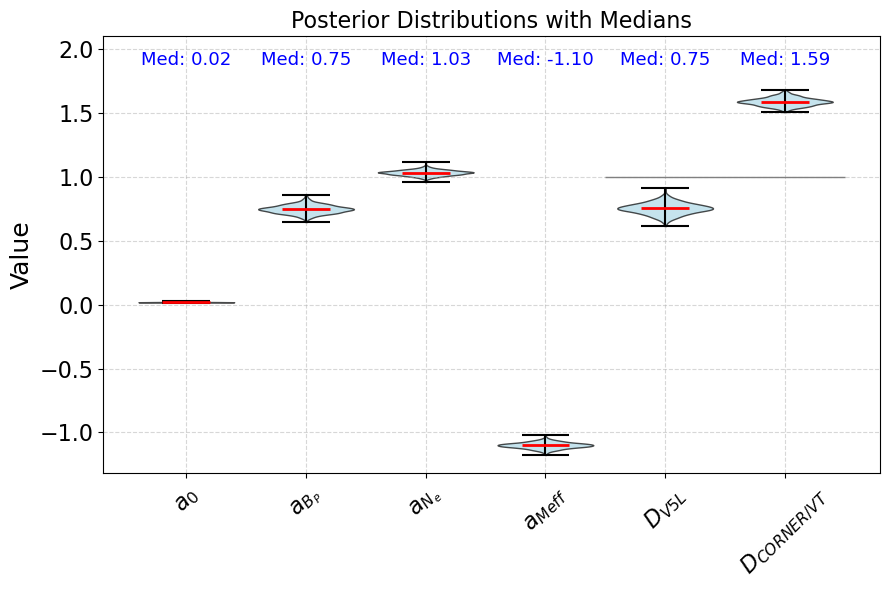

1000 samples' RMSE: 0.1636
1000 samples' RMSE: 0.0115


In [26]:
import numpy as np
import matplotlib.pyplot as plt
import arviz as az
from sklearn.metrics import mean_squared_error

# 从 trace 中提取 1000 次后验样本
posterior_samples = az.extract(trace, num_samples=1000)
posterior_array = {k: np.array(v) for k, v in posterior_samples.items()}

# 修改后的变量名称列表（用于x轴标签）
titles = ["$a_0$", "sigma", "$a_{B_P}$", "$a_{N_e}$", "$a_{Meff}$", 
          "$D_{V5L}$", "$D_{CORNER/VT}$"]

D = 7
log_transform_indices = [0, 5, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]

data = []
filtered_indices = []
gamma_prob_0 = []
medians = []

for i in range(D):
    varname = list(posterior_array.keys())[i]
    samples = posterior_array[varname]
    
    if i == 1 or i == 13:  # 排除 sigma、D_{V5E}, D_{V5C}
        continue

    filtered_indices.append(i)

    if i in log_transform_indices:
        samples = np.exp(samples)
    data.append(samples)
    medians.append(np.median(samples))

    gamma_varname = f'gamma_{varname}'
    if gamma_varname in posterior_array:
        prob_0 = np.mean(posterior_array[gamma_varname] < 0.5)
    else:
        prob_0 = 0
    gamma_prob_0.append(prob_0)

# 绘图
plt.figure(figsize=(9, 6))
violin_parts = plt.violinplot(data, 
                               showmeans=False, 
                               showmedians=True,
                               showextrema=True,
                               widths=0.8)

for pc in violin_parts['bodies']:
    pc.set_facecolor('lightblue')
    pc.set_edgecolor('black')
    pc.set_alpha(0.7)
violin_parts['cmedians'].set_color('red')
violin_parts['cmedians'].set_linewidth(2)
violin_parts['cmaxes'].set_color('black')
violin_parts['cmins'].set_color('black')
violin_parts['cbars'].set_color('black')

xticks_pos = range(1, len(data)+1)
plt.xticks(xticks_pos, 
           [titles[i] for i in filtered_indices], 
           rotation=45, 
           ha='center',
           fontsize=18)

start_idx = 5  # D_VERTPLT 相关的起点
x_start = filtered_indices.index(start_idx) + 1
ax = plt.gca()
ax.hlines(y=1.0, xmin=x_start-0.5, xmax=len(data)+0.5,
          colors='grey', linestyles='-', linewidth=1)

# 添加中位数与概率标注
y_max = plt.ylim()[1]
for pos, i, med in zip(xticks_pos, filtered_indices, medians):
    plt.text(pos, y_max*1.01, f"Med: {med:.2f}", 
             ha='center', va='bottom', fontsize=13, color='blue')
    prob = gamma_prob_0[filtered_indices.index(i)]
    if prob > 0:
        plt.text(pos, y_max*1.07, f"$P$: {prob:.2f}", 
                 ha='center', va='bottom', fontsize=13, color='darkred')

# 细节设置
plt.grid(True, linestyle='--', alpha=0.5)
plt.ylabel('Value', fontsize=18)
plt.title('Posterior Distributions with Medians', fontsize=16)
plt.tick_params(axis='both', which='major', labelsize=16)
plt.ylim(plt.ylim()[0], y_max*1.15)
plt.tight_layout()
#plt.savefig('violin_trace_posteriors_new_median_rmse.png', format='png', dpi=300, transparent=True)
plt.show()

from sklearn.metrics import mean_squared_error
pred_mean = predictions.mean(axis=0)  # 转置后按列平均，得到 shape (483,)

y = y.ravel()
rmse = np.sqrt(mean_squared_error(np.log(y), np.log(pred_mean)))
print(f"1000 samples' RMSE: {rmse:.4f}")


rmse = np.sqrt(mean_squared_error(y, pred_mean))
print(f"1000 samples' RMSE: {rmse:.4f}")


In [8]:
import pymc as pm
import numpy as np
import arviz as az
import pandas as pd

file_path = 'LH_metal_DB_v1.12.csv'  # 替换为你的文件路径
df = pd.read_csv(file_path)
df.loc[:, 'TOK'] = df['TOK'].str.strip()
df['IP']=df['IP'].abs()/1000000
df['BT']=df['BT'].abs()
df['PLTH']=df['PLTH']/1000000
df['NEL']=df['NEL']/1e19


df.loc[:, 'TOK'] = df['TOK'].str.strip()

reference_dict = {
    1.00:  "Hydrogen",
    2.00:  "Deuterium",
    2.50:  "Deuterium and tritium",
    3.00:  "3He or tritium",
    4.00:  "4He",
    14.01: "Nitrogen"
}

# 定义一个函数，用来根据某一观测值PGASA，返回对应的分类名称
def categorize_pgasa(value, ref_dict, tolerance=0.2):
    """
    value: 待分类的数值
    ref_dict: {参考值: 分类名称}
    tolerance: 容忍度，即 |value - 参考值| 需小于等于该值才视为同一类
    """
    # 1) 找到离 value 最近的参考值
    closest_ref = min(ref_dict.keys(), key=lambda x: abs(x - value))
    # 2) 判断两者差值是否在容忍度以内
    if abs(closest_ref - value) <= tolerance:
        return ref_dict[closest_ref]
    else:
        return np.nan  # 或者 "Other"

# 将 categorize_pgasa 应用于 df["PGASA"] 列，生成新的分类列
df["Category"] = df["PGASA"].apply(lambda x: categorize_pgasa(x, reference_dict, tolerance=0.1))

# 如果需要查看分类结果
print(df)



# 假设 subset1 是你的数据框
colors = df['SELEC2024'].map({1: 'red', 0: 'blue'})
x = df['NEL']
y = df['PLTH']
bt = df['BT'].abs()
ip= df['IP']

# 分类 BT 值
#subset2_2 = df[(ip < 2.6) & (ip >=2.4)&(bt < 3.2) & (bt >=2.8)& (df['Category'] == 'Deuterium')& (df['DIVCON'] == 'VT')]
#df = df.drop(subset2_2.index)
print(df)
import statsmodels.api as sm

# 指定你想在新 DataFrame 中包含的列
columns_to_include = ['TOK', 'SPLASMA','BT','IP','RGEO','PLTH','NEL','PGASA',"DIVCON"]
new_df = df[df['SELEC2024'] == 1][columns_to_include].copy()
mu0 = 4 * np.pi * 1e-7

new_df['BP']=1000000*(mu0 * new_df['IP']) / (new_df['SPLASMA']/(2 * np.pi * new_df['RGEO']))

new_df['PLTH/S/2']=new_df['PLTH']/(new_df['SPLASMA']*2)
#new_df['PLTH/S/2']=new_df['PLTH']
# 显示新 DataFrame
print("New DataFrame:")
print(new_df)


columns_to_include_for_regre = ['BP','PLTH/S/2','NEL','PGASA']
unique_divcon = new_df['DIVCON'].unique()


for divcon_type in unique_divcon:
    new_df[divcon_type] = (new_df['DIVCON'] == divcon_type).astype(int)
multi_df = new_df[columns_to_include_for_regre].copy()

x = multi_df[['BP','NEL','PGASA']] 

x[unique_divcon] = new_df[unique_divcon]
x.drop(['Xptref','Xpthigh','Xptin'], axis=1, inplace=True)
x['CV'] = x[['CORNER','VT']].max(axis=1)
x.drop(['V5E','V5C','HT3R','STANDARD','V5','CORNER','VT',' VERTPLT'], axis=1, inplace=True)

y=multi_df["PLTH/S/2"]

      TOK        SHOT      TIME PHASE  PGASA      RGEO      AMIN    KAPPA  \
0    CMOD  1050428004   0.63461    LH  2.000  0.672389  0.216421  1.69737   
1    CMOD  1050428007   0.66603    LH  2.000  0.670773  0.217660  1.67073   
2    CMOD  1050621015   0.91039    LH  2.000  0.672785  0.217388  1.67962   
3    CMOD  1050621029   0.85420    LH  2.000  0.670869  0.217080  1.69789   
4    CMOD  1050623008   0.80070    LH  2.000  0.678764  0.213690  1.44202   
..    ...         ...       ...   ...    ...       ...       ...      ...   
685   JET       90527  50.99500    LH  1.962  2.900090  0.933780  1.66731   
686   JET       90528  55.16500    LH  1.916  2.901440  0.933319  1.66831   
687   JET       90737  54.56500    LH  1.940  2.901330  0.934255  1.66599   
688   JET       90738  54.46500    LH  1.961  2.898400  0.937640  1.65848   
689   JET       90742  52.16500    LH  1.983  2.900930  0.933565  1.66813   

       SPLASMA CONFIG  ...       PL     PLTH    PFLOSS PRADCORE    DIVCON  

In [24]:
import numpy as np

posterior = trace.posterior

# 把参数展开成 (chain * draw,) 形状的数组
a_samples = posterior['a'].stack(sample=('chain', 'draw')).values
alpha1_samples = posterior['alpha1'].stack(sample=('chain', 'draw')).values
alpha2_samples = posterior['alpha2'].stack(sample=('chain', 'draw')).values
alpha3_samples = posterior['alpha3'].stack(sample=('chain', 'draw')).values
alpha4_samples = posterior['alpha4'].stack(sample=('chain', 'draw')).values
alpha5_samples = posterior['alpha5'].stack(sample=('chain', 'draw')).values

# 取前1000个采样
num_samples = 1000
a_samples = a_samples[:num_samples]
alpha1_samples = alpha1_samples[:num_samples]
alpha2_samples = alpha2_samples[:num_samples]
alpha3_samples = alpha3_samples[:num_samples]
alpha4_samples = alpha4_samples[:num_samples]
alpha5_samples = alpha5_samples[:num_samples]

N_data = len(x['BP'])

x_BP = x['BP'].values
x_NEL = x['NEL'].values
x_PGASA = x['PGASA'].values
x_V5L = x['V5L'].values
x_CV = x['CV'].values

# 计算预测值，利用广播矢量化
a1 = np.exp(a_samples)[:, None]   # (1000,1)
f = a1 * (x_BP ** alpha1_samples[:, None]) * (x_NEL ** alpha2_samples[:, None]) * (x_PGASA ** alpha3_samples[:, None]) * \
    np.exp(alpha4_samples[:, None] * x_V5L) * np.exp(alpha5_samples[:, None] * x_CV)  # (1000, N_data)

predictions = f  # predictions是形状(1000, N_data)的预测结果矩阵
#predictions = predictions.mean(axis=1)  # 对每个数据点，在1000次采样中取均值
predictions

array([[0.14396304, 0.10514316, 0.12556433, ..., 0.02312645, 0.0283745 ,
        0.02660278],
       [0.14438228, 0.10486567, 0.12646675, ..., 0.02315195, 0.02852592,
        0.02667081],
       [0.14351251, 0.10358749, 0.1260083 , ..., 0.02308567, 0.02856441,
        0.02664812],
       ...,
       [0.1427399 , 0.10413602, 0.12472366, ..., 0.02316976, 0.02845434,
        0.02665617],
       [0.14556868, 0.10606433, 0.12680705, ..., 0.02318371, 0.02848676,
        0.02669779],
       [0.14550486, 0.10642989, 0.12668547, ..., 0.02330136, 0.02855987,
        0.02679543]])

RMSE (log-scale): 0.1636


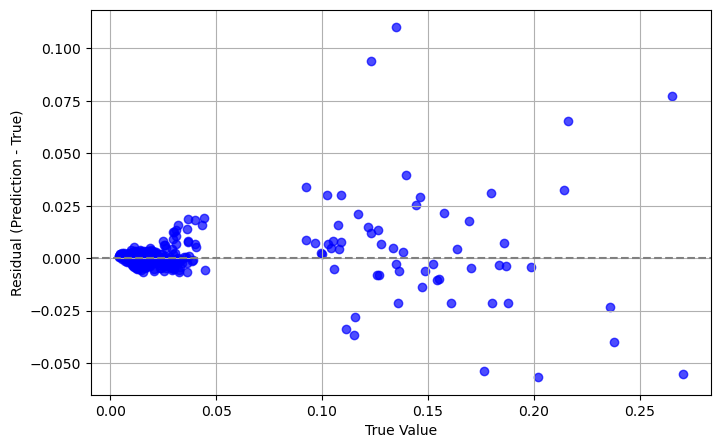

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# 假设 f_mean 是你已经算好的预测均值，y 是真实值（numpy array 或 pandas Series）

# 计算对数RMSE
rmse = np.sqrt(mean_squared_error(np.log(y), np.log(pred_mean)))
print(f"RMSE (log-scale): {rmse:.4f}")

# 计算残差（原始数据空间）
residuals = pred_mean - y

# 画残差图
plt.figure(figsize=(8,5))
plt.scatter(y, residuals, alpha=0.7, color='blue')
plt.axhline(0, linestyle='--', color='gray')
plt.xlabel("True Value")
plt.ylabel("Residual (Prediction - True)")
#plt.title("Residual Plot (Original Scale)")
plt.grid(True)
plt.savefig('residue2.png', format='png', dpi=300, transparent=True)
plt.show()


In [ ]:
import pymc as pm
import numpy as np
import arviz as az
import matplotlib.pyplot as plt

# 对数化变量
log_x1 = np.log(x1_obs)
log_x2 = np.log(x2_obs)
log_y = np.log(y_obs)
log_sigma_y = sigma_y / y_obs  # 误差传播到 log(y)

# 对数线性模型
with pm.Model() as log_linear_model:
    b = pm.Normal("b", mu=0, sigma=5)
    alpha1 = pm.Normal("alpha1", mu=0, sigma=5)
    alpha2 = pm.Normal("alpha2", mu=0, sigma=5)
    
    mu = b + alpha1 * log_x1 + alpha2 * log_x2
    Y_log = pm.Normal("Y_log", mu=mu, sigma=1, observed=log_y)
    
    log_trace = pm.sample(2000, tune=2000, return_inferencedata=True)
import matplotlib.pyplot as plt
az.plot_trace(log_trace)
plt.show()
summary1=az.summary(log_trace)
print(summary1)

/var/folders/5g/7cwc8n193kz9d4h5lc3ky_0c0000gn/T/ipykernel_21608/795044754.py:44: UserWarning: Glyph 35266 (\N{CJK UNIFIED IDEOGRAPH-89C2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5g/7cwc8n193kz9d4h5lc3ky_0c0000gn/T/ipykernel_21608/795044754.py:44: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5g/7cwc8n193kz9d4h5lc3ky_0c0000gn/T/ipykernel_21608/795044754.py:44: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5g/7cwc8n193kz9d4h5lc3ky_0c0000gn/T/ipykernel_21608/795044754.py:44: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5g/7cwc8n193kz9d4h5lc3ky_0c0000gn/T/ipykernel_21608/795044754.py:44: UserWarning: Glyph 38750 (\N{CJK UNIFIED IDEOGRAPH-975E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5g/7cwc8n193

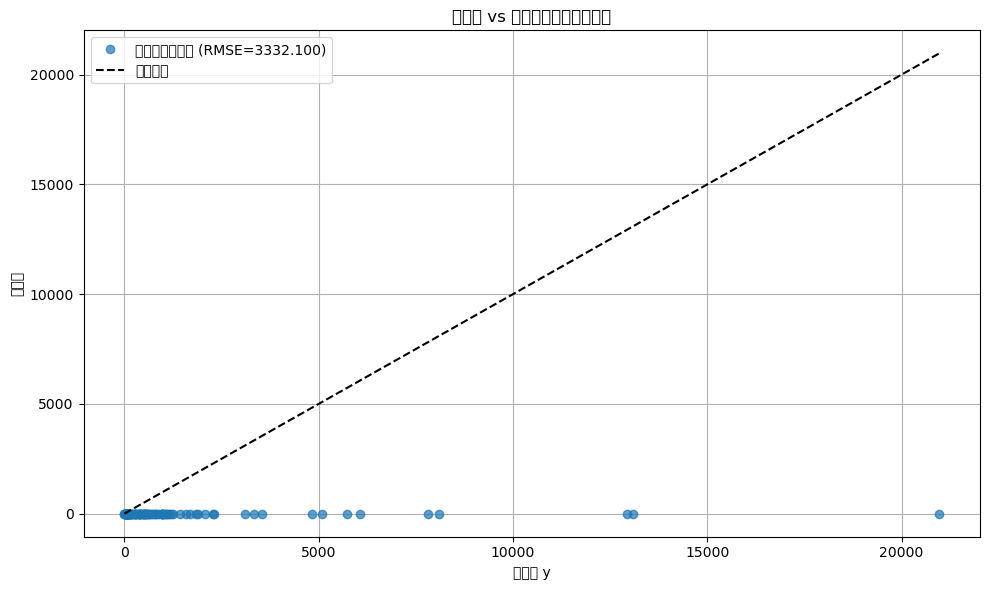

In [162]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# 从 posterior 中采样 100 次
samples = 100
a_samples = trace.posterior["a"].values.reshape(-1)[:samples]
alpha1_samples = trace.posterior["alpha1"].values.reshape(-1)[:samples]
alpha2_samples = trace.posterior["alpha2"].values.reshape(-1)[:samples]
alpha3_samples = trace.posterior["alpha3"].values.reshape(-1)[:samples]
alpha4_samples = trace.posterior["alpha4"].values.reshape(-1)[:samples]
alpha5_samples = trace.posterior["alpha5"].values.reshape(-1)[:samples]

b_samples = log_trace.posterior["b"].values.reshape(-1)[:samples]
alpha1_log_samples = log_trace.posterior["alpha1"].values.reshape(-1)[:samples]
alpha2_log_samples = log_trace.posterior["alpha2"].values.reshape(-1)[:samples]

# 计算非线性模型的预测平均
y_preds_nonlin = np.array([
    np.exp(a) * x1_obs**alpha1 * x2_obs**alpha2
    for a, alpha1, alpha2 in zip(a_samples, alpha1_samples, alpha2_samples)
])
y_pred_nonlin = y_preds_nonlin.mean(axis=0)

'''# 对数线性模型预测，转换回 y 空间后求平均
log_y_preds = np.array([
    b + alpha1 * log_x1 + alpha2 * log_x2
    for b, alpha1, alpha2 in zip(b_samples, alpha1_log_samples, alpha2_log_samples)
])
y_preds_loglin = np.exp(log_y_preds)
y_pred_loglin = y_preds_loglin.mean(axis=0)
'''
# 计算 RMSE
rmse_nonlin = np.sqrt(mean_squared_error(y_obs, y_pred_nonlin))
#rmse_loglin = np.sqrt(mean_squared_error(y_obs, y_pred_loglin))

# 可视化
plt.figure(figsize=(10, 6))
plt.plot(y_obs, y_pred_nonlin, "o", label=f"非线性模型预测 (RMSE={rmse_nonlin:.3f})", alpha=0.7)
#plt.plot(y_obs, y_pred_loglin, "x", label=f"对数线性预测 (RMSE={rmse_loglin:.3f})", alpha=0.7)
plt.plot([min(y_obs), max(y_obs)], [min(y_obs), max(y_obs)], "k--", label="理想预测")
plt.xlabel("观测值 y")
plt.ylabel("预测值")
plt.legend()
plt.title("非线性 vs 对数线性模型预测对比")
plt.grid(True)
plt.tight_layout()
plt.show()


In [209]:
import numpy as np
from scipy.stats import norm
from scipy.optimize import minimize

np.random.seed(42)
mu_x, sigma_x = 1, 0.5
samples_x = np.random.normal(mu_x, sigma_x, 1_000_000)
samples_x = samples_x[samples_x > 0]  # 必须 x > 0
samples_y = np.log(samples_x)
samples_y = samples_y[(samples_y >= -1) & (samples_y <= 1)]  # 限制范围

In [210]:
def neg_log_likelihood(params, data):
    """负对数似然函数（因为 scipy.optimize 最小化）"""
    mu, sigma = params
    n = len(data)
    return n/2 * np.log(2*np.pi) + n * np.log(sigma) + 1/(2*sigma**2) * np.sum((data - mu)**2)

# 初始猜测（例如样本均值和标准差）
initial_guess = [np.mean(samples_y), np.std(samples_y)]

In [211]:
result = minimize(
    fun=neg_log_likelihood,
    x0=initial_guess,
    args=(samples_y,),
    bounds=[(None, None), (1e-6, None)]  # sigma > 0
)

mu_mle, sigma_mle = result.x
print(f"MLE 结果: μ = {mu_mle:.4f}, σ = {sigma_mle:.4f}")

MLE 结果: μ = 0.0164, σ = 0.4058


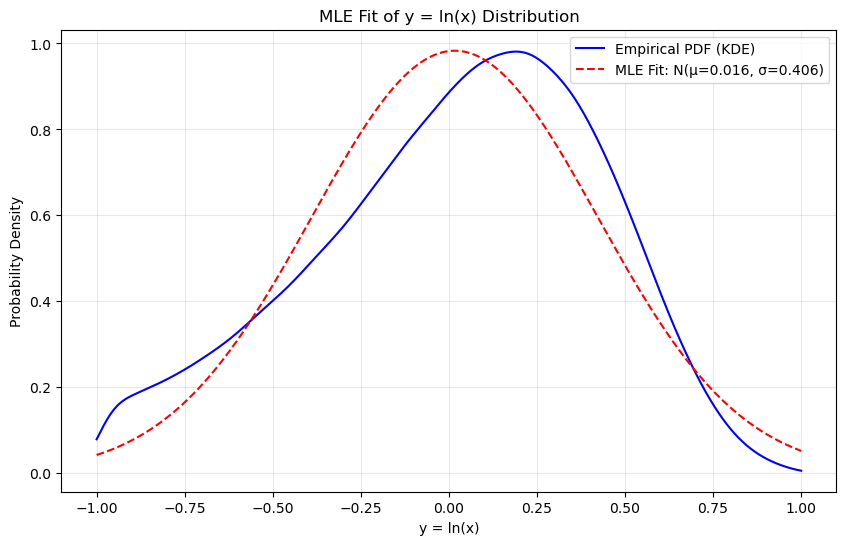

In [212]:
import matplotlib.pyplot as plt

# 绘制 KDE
from scipy.stats import gaussian_kde
kde = gaussian_kde(samples_y, bw_method=0.4)
y_grid = np.linspace(-1, 1, 1000)
pdf_kde = kde(y_grid)

# 绘制 MLE 拟合的正态分布
pdf_mle = norm.pdf(y_grid, loc=mu_mle, scale=sigma_mle)

plt.figure(figsize=(10, 6))
plt.plot(y_grid, pdf_kde, 'b-', label='Empirical PDF (KDE)')
plt.plot(y_grid, pdf_mle, 'r--', label=f'MLE Fit: N(μ={mu_mle:.3f}, σ={sigma_mle:.3f})')
plt.xlabel('y = ln(x)')
plt.ylabel('Probability Density')
plt.title('MLE Fit of y = ln(x) Distribution')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [222]:
rmse = np.sqrt(np.mean((pdf_kde - pdf_mle) ** 2))
print(f"RMSE = {rmse:.6f}")

RMSE = 0.105519


In [217]:
import numpy as np
from scipy.optimize import minimize

np.random.seed(42)
mu_true, sigma_true = 1, 0.5
samples_x = np.random.normal(mu_true, sigma_true, 10000)
samples_x = samples_x[samples_x > 0]  # 必须 x > 0
samples_y = np.log(samples_x)
samples_y = samples_y[(samples_y >= -1) & (samples_y <= 1)]  # 限制范围

In [218]:
def neg_log_likelihood(params, y_data):
    mu, sigma = params
    n = len(y_data)
    x_data = np.exp(y_data)  # y = ln(x) ⇒ x = e^y
    term1 = n/2 * np.log(2 * np.pi)
    term2 = n * np.log(sigma)
    term3 = np.sum((x_data - mu)**2) / (2 * sigma**2)
    term4 = -np.sum(y_data)  # 因为 f_Y(y) 包含 e^y 项
    return term1 + term2 + term3 + term4

In [219]:
initial_guess = [1.0, 0.5]  # 初始猜测 (μ, σ)
result = minimize(
    fun=neg_log_likelihood,
    x0=initial_guess,
    args=(samples_y,),
    bounds=[(None, None), (1e-6, None)]  # σ > 0
)

mu_mle, sigma_mle = result.x
print(f"MLE 结果: μ = {mu_mle:.4f}, σ = {sigma_mle:.4f}")

MLE 结果: μ = 1.0997, σ = 0.4199


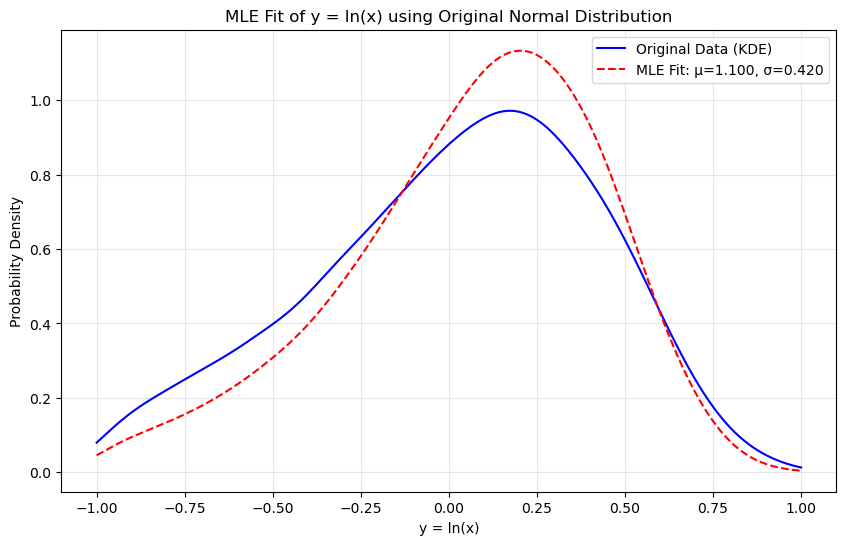

In [220]:
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# 用 MLE 估计的参数生成新的 x 和 y
samples_x_mle = np.random.normal(mu_mle, sigma_mle, 100000)
samples_x_mle = samples_x_mle[samples_x_mle > 0]
samples_y_mle = np.log(samples_x_mle)
samples_y_mle = samples_y_mle[(samples_y_mle >= -1) & (samples_y_mle <= 1)]

# 计算 KDE
kde_original = gaussian_kde(samples_y, bw_method=0.2)
kde_mle = gaussian_kde(samples_y_mle, bw_method=0.2)
y_grid = np.linspace(-1, 1, 10000)

# 绘图
plt.figure(figsize=(10, 6))
plt.plot(y_grid, kde_original(y_grid), 'b-', label='Original Data (KDE)')
plt.plot(y_grid, kde_mle(y_grid), 'r--', label=f'MLE Fit: μ={mu_mle:.3f}, σ={sigma_mle:.3f}')
plt.xlabel('y = ln(x)')
plt.ylabel('Probability Density')
plt.title('MLE Fit of y = ln(x) using Original Normal Distribution')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [221]:
rmse = np.sqrt(np.mean((kde_original(y_grid) - kde_mle(y_grid))**2))
print(f"RMSE = {rmse:.6f}")

RMSE = 0.089968


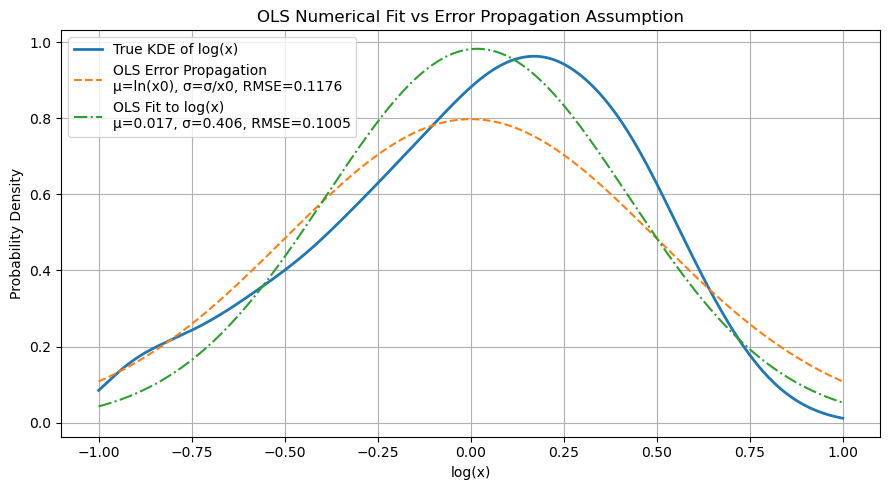

In [228]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, gaussian_kde
from sklearn.metrics import mean_squared_error

# 参数
x0 = 1.0
sigma_x = 0.5
n_samples = 100000

# 生成样本
np.random.seed(42)
samples_x = np.random.normal(x0, sigma_x, n_samples)
samples_x = samples_x[samples_x > 0]  # 去掉非正数
samples_y = np.log(samples_x)
samples_y = samples_y[(samples_y >= -1) & (samples_y <= 1)]

# 真实分布 KDE
kde = gaussian_kde(samples_y, bw_method=0.2)
y_grid = np.linspace(-1, 1, 10000)
pdf_true = kde(y_grid)

# ---------- 方法一：OLS误差传播假设 ----------
mu_ols = np.log(x0)
sigma_ols = sigma_x / x0
pdf_ols = norm.pdf(y_grid, loc=mu_ols, scale=sigma_ols)
rmse_ols = np.sqrt(mean_squared_error(pdf_true, pdf_ols))

# ---------- 方法二：最小二乘拟合分布 ----------
# 等价于直接计算 log(x) 的均值和标准差
mu_fit = np.mean(samples_y)
sigma_fit = np.std(samples_y)
pdf_fit = norm.pdf(y_grid, loc=mu_fit, scale=sigma_fit)
rmse_fit = np.sqrt(mean_squared_error(pdf_true, pdf_fit))

# ---------- 绘图 ----------
plt.figure(figsize=(9, 5))
plt.plot(y_grid, pdf_true, label='True KDE of log(x)', linewidth=2)
plt.plot(y_grid, pdf_ols, '--', label=f'OLS Error Propagation\nμ=ln(x0), σ=σ/x0, RMSE={rmse_ols:.4f}')
plt.plot(y_grid, pdf_fit, '-.', label=f'OLS Fit to log(x)\nμ={mu_fit:.3f}, σ={sigma_fit:.3f}, RMSE={rmse_fit:.4f}')
plt.xlabel('log(x)')
plt.ylabel('Probability Density')
plt.title('OLS Numerical Fit vs Error Propagation Assumption')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
